# Fixation mRNN Model Selection

**Question 1 (this notebook's main result).** Which regional recurrent connectivity
architecture is actually needed to reproduce the regional PC trajectories?

- `full` — every region-to-region recurrent block is free.
- `within_region` — only each region's internal block; regions are coupled by nothing.
- `cross_region_with_self_diagonal` — only cross-region blocks, plus a diagonal inside
  each region so a unit can still feed back to itself.

**Question 2 (second half).** Given that architecture, how low can the *rank* of the
inter-regional coupling go before the fit degrades?

The three architectures do not have the same number of free parameters, so a raw loss
comparison is not a model comparison. This notebook therefore reports fit quality
alongside four separate ways of accounting for capacity:

| Section | Approach | Needs retraining? |
|---|---|---|
| 5 | Raw fit quality (PC-space and firing-rate-space R^2), convergence check | no |
| 6 | Complexity-penalized in-sample criteria (AIC/BIC, nested F-test) | no |
| 7 | Fit-vs-parameter-count curves across the h40/h50 runs, plus exact capacity-matched configs | curves no, matched configs yes |
| 8 | Connection ablation inside the trained `full` model — parameter-count-free | no |
| 9 | Effective rank of the learned inter-regional blocks — bridges to the bottleneck question | no |

Section 6 is included mainly to show *why* it cannot settle the question here: these
models carry roughly as many free parameters as the dataset has numbers. Sections 7-9
are the ones the architecture claim should rest on.

## 1. Setup

In [1]:
from dataclasses import replace
from io import BytesIO
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from dal_monte_2022_analysis.ephys.modeling import (
    backproject_replay_outputs_to_firing_rates,
    load_fixation_mrnn_config,
    pc_reconstructed_firing_rate_accuracy,
    reconstruction_accuracy,
    resolve_fixation_mrnn_output_root,
    settings_from_config,
)
from dal_monte_2022_analysis.ephys.modeling.fixation_mrnn_model import (
    FixationMRNNModel,
    FixationMRNNModelSpec,
    normalize_recurrent_connectivity,
)

DEVICE = "cpu"  # every model here is small; replay on CPU keeps the notebook portable


def display_figure(fig, *, dpi=150):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))


# One fixed hue per architecture, used identically in every figure below.
# Okabe-Ito steps: colorblind-safe and separable in grayscale print.
ARCH_COLORS = {
    "full": "#0072B2",
    "cross_region_with_self_diagonal": "#D55E00",
    "within_region": "#009E73",
}
ARCH_LABELS = {
    "full": "full",
    "cross_region_with_self_diagonal": "cross + self-diagonal",
    "within_region": "within-region only",
}
ARCH_ORDER = ["full", "cross_region_with_self_diagonal", "within_region"]
SEQUENTIAL_HUE = plt.get_cmap("Blues")  # magnitude ramp for the bottleneck sweep

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

In [2]:
cfg = load_fixation_mrnn_config(repo_root / "configs" / "ephys_fixation_mrnn.yaml")
base_settings = settings_from_config(cfg)
base_settings.dataset_cfg_path = str(repo_root / "configs" / "dataset.yaml")
SCRATCH_ROOT = resolve_fixation_mrnn_output_root(base_settings) / "scratch"
print(SCRATCH_ROOT)
print("exists:", SCRATCH_ROOT.exists())

/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch
exists: True


## 2. Run inventory

Everything below reads the *saved* runs. Each `checkpoint_final.pth` carries the exact
`settings` and `model_spec` it was trained with, so the configuration reported here is
the trained configuration, not a re-derivation from the current config file.

In [3]:
CONNECTIVITY_RUNS = {
    # label -> scratch run id
    "h40_full": "cca_42pc_tanh_h40_full",
    "h40_cross": "cca_42pc_tanh_h40_cross_region_with_self_diagonal",
    "h40_within": "cca_42pc_tanh_h40_within_region",
    "h50_full": "cca_42pc_tanh_h50_full",
    "h50_cross": "cca_42pc_tanh_h50_cross_region_with_self_diagonal",
    "h50_within": "cca_42pc_tanh_h50_within_region",
}

BOTTLENECK_RUNS = {f"rank_{dim}": f"bottleneck_dim_{dim}" for dim in (1, 2, 3, 4, 5, 10, 20, 30)}

_CHECKPOINT_CACHE: dict[str, dict] = {}


def run_dir_for(run_id: str) -> Path:
    return SCRATCH_ROOT / run_id


def load_checkpoint(run_id: str) -> dict:
    """Load and memoize a run checkpoint."""
    if run_id not in _CHECKPOINT_CACHE:
        _CHECKPOINT_CACHE[run_id] = torch.load(
            run_dir_for(run_id) / "checkpoint_final.pth",
            map_location=DEVICE,
            weights_only=False,
        )
    return _CHECKPOINT_CACHE[run_id]


def load_history(run_id: str) -> pd.DataFrame:
    return pd.read_csv(run_dir_for(run_id) / "history.csv")


def is_legacy_dense_checkpoint(checkpoint) -> bool:
    """True when the checkpoint predates the low-rank block parameterization.

    Pre-bottleneck runs stored a single dense masked ``mrnn.W_rec``. Runs after the
    low-rank refactor store ``_within_region_param_*`` / ``_inter_left_*`` /
    ``_inter_right_*`` blocks instead, and rebuild ``W_rec`` from them.
    """
    return not any(str(key).startswith("_within_region_param_") for key in checkpoint["model_state_dict"])


def describe_run(label: str, run_id: str) -> dict:
    checkpoint = load_checkpoint(run_id)
    settings = checkpoint["settings"]
    spec = checkpoint["model_spec"]
    manifest_path = run_dir_for(run_id) / "manifest.json"
    manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}
    history = load_history(run_id)
    return {
        "label": label,
        "run_id": run_id,
        "connectivity": normalize_recurrent_connectivity(settings["recurrent_connectivity"]),
        "bottleneck_dim": settings.get("recurrent_bottleneck_dim"),
        "hidden_units": settings.get("hidden_units"),
        "activation": settings.get("activation"),
        "spectral_radius": settings.get("spectral_radius"),
        "n_pcs": settings.get("pca_n_components"),
        "epochs": int(settings.get("epochs")),
        "iterations_run": int(len(history)),
        "lr": settings.get("lr"),
        "deriv_scale": settings.get("temporal_derivative_loss_scale"),
        "curv_scale": settings.get("temporal_curvature_loss_scale"),
        "l1_weight_scale": settings.get("l1_weight_scale"),
        "train_initial_state": settings.get("train_initial_state"),
        "final_total_loss": float(history["loss"].iloc[-1]),
        "final_recon_loss": float(history["reconstruction_loss"].iloc[-1]),
        "legacy_dense_checkpoint": is_legacy_dense_checkpoint(checkpoint),
        "trained_at": manifest.get("created_at_utc", ""),
    }


inventory = pd.DataFrame(
    [describe_run(label, run_id) for label, run_id in CONNECTIVITY_RUNS.items()]
    + [describe_run(label, run_id) for label, run_id in BOTTLENECK_RUNS.items()]
)
display(inventory)

,label,run_id,connectivity,bottleneck_dim,hidden_units,activation,spectral_radius,n_pcs,epochs,iterations_run,lr,deriv_scale,curv_scale,l1_weight_scale,train_initial_state,final_total_loss,final_recon_loss,legacy_dense_checkpoint,trained_at
0,h40_full,cca_42pc_tanh_h40_full,full,NaN,40,tanh,1.1,42,50000,50000,0.0003,1.0,0.5,0.00,True,0.000242,0.000175,True,2026-06-24T16:58:23.312461+00:00
1,h40_cross,cca_42pc_tanh_h40_cross_region_with_self_diagonal,cross_region_with_self_diagonal,NaN,40,tanh,1.1,42,50000,50000,0.0003,1.0,0.5,0.00,True,0.001123,0.000945,True,2026-06-24T18:46:42.640129+00:00
2,h40_within,cca_42pc_tanh_h40_within_region,within_region,NaN,40,tanh,1.1,42,50000,50000,0.0003,1.0,0.5,0.00,True,0.001079,0.000855,True,2026-06-24T17:53:25.224668+00:00
3,h50_full,cca_42pc_tanh_h50_full,full,NaN,50,tanh,1.1,42,50000,50000,0.0003,1.0,0.5,0.00,True,0.000055,0.000032,True,2026-06-24T06:01:25.191417+00:00
4,h50_cross,cca_42pc_tanh_h50_cross_region_with_self_diagonal,cross_region_with_self_diagonal,NaN,50,tanh,1.1,42,50000,50000,0.0003,1.0,0.5,0.00,True,0.000088,0.000054,True,2026-06-24T07:47:15.608387+00:00
5,h50_within,cca_42pc_tanh_h50_within_region,within_region,NaN,50,tanh,1.1,42,50000,50000,0.0003,1.0,0.5,0.00,True,0.001081,0.000903,True,2026-06-24T06:54:27.396504+00:00
6,rank_1,bottleneck_dim_1,full,1.0,50,tanh,1.1,42,100000,100000,0.0003,1.0,0.5,0.01,True,0.000925,0.000245,False,2026-06-30T22:36:48.574504+00:00
7,rank_2,bottleneck_dim_2,full,2.0,50,tanh,1.1,42,100000,100000,0.0003,1.0,0.5,0.01,True,0.000689,0.000261,False,2026-07-01T00:38:58.369892+00:00
8,rank_3,bottleneck_dim_3,full,3.0,50,tanh,1.1,42,100000,100000,0.0003,1.0,0.5,0.01,True,0.000349,0.000173,False,2026-07-01T02:41:17.818485+00:00
9,rank_4,bottleneck_dim_4,full,4.0,50,tanh,1.1,42,100000,100000,0.0003,1.0,0.5,0.01,True,0.000335,0.000177,False,2026-07-01T04:41:39.612195+00:00


### 2a. Were the connectivity models fit with an inter-regional bottleneck?

**No.** The six `cca_42pc_tanh_*` runs were trained before the low-rank inter-regional
parameterization existed. Their checkpoints store a single dense masked recurrent matrix
(`mrnn.W_rec` plus `mrnn.W_rec_mask`) and carry `recurrent_bottleneck_dim = None`. Every
allowed region-to-region block in those runs is a **free, full-rank** matrix.

The rank constraint (`left @ right` with `recurrent_bottleneck_dim` columns) was added
later and is what the `bottleneck_dim_*` runs use. The cell below verifies both claims
directly from the stored tensors rather than from the config file, and reports the
numerical rank of each fitted inter-regional block.

In [4]:
def region_slices_from_spec(spec) -> dict[str, slice]:
    """Region-ordered hidden-state slices, matching mrnntorch's registration order."""
    slices = {}
    start = 0
    for region in spec["region_order"]:
        stop = start + int(spec["hidden_units_by_region"][region])
        slices[region] = slice(start, stop)
        start = stop
    return slices


def dense_recurrent_matrix(run_id: str) -> tuple[np.ndarray, np.ndarray, dict[str, slice]]:
    """Return (effective W_rec, structural mask, region slices) for any run vintage."""
    checkpoint = load_checkpoint(run_id)
    state = checkpoint["model_state_dict"]
    spec = checkpoint["model_spec"]
    slices = region_slices_from_spec(spec)
    mask = state["mrnn.W_rec_mask"].detach().cpu().numpy().astype(float)
    if is_legacy_dense_checkpoint(checkpoint):
        weight = state["mrnn.W_rec"].detach().cpu().numpy().astype(float) * mask
        return weight, mask, slices
    # Rebuild the dense matrix from the low-rank / diagonal block parameters.
    mode = normalize_recurrent_connectivity(checkpoint["settings"]["recurrent_connectivity"])
    total = int(sum(int(spec["hidden_units_by_region"][r]) for r in spec["region_order"]))
    weight = np.zeros((total, total), dtype=float)
    rebuilt_mask = np.zeros_like(weight)
    for region in spec["region_order"]:
        param = state[f"_within_region_param_{region}"].detach().cpu().numpy().astype(float)
        block = np.diag(param) if param.ndim == 1 else param
        weight[slices[region], slices[region]] = block
        rebuilt_mask[slices[region], slices[region]] = (
            np.eye(block.shape[0]) if param.ndim == 1 else np.ones_like(block)
        )
    for source in spec["region_order"]:
        for target in spec["region_order"]:
            key_left = f"_inter_left_{source}_{target}"
            if key_left not in state:
                continue
            left = state[key_left].detach().cpu().numpy().astype(float)
            right = state[f"_inter_right_{source}_{target}"].detach().cpu().numpy().astype(float)
            block = left @ right
            weight[slices[target], slices[source]] = block
            rebuilt_mask[slices[target], slices[source]] = 1.0
    return weight, rebuilt_mask, slices


def inter_regional_block_ranks(run_id: str, *, tol_ratio: float = 1e-6) -> pd.DataFrame:
    """Numerical rank and participation ratio of every cross-region block."""
    weight, mask, slices = dense_recurrent_matrix(run_id)
    checkpoint = load_checkpoint(run_id)
    regions = list(checkpoint["model_spec"]["region_order"])
    rows = []
    for source in regions:
        for target in regions:
            if source == target:
                continue
            block = weight[slices[target], slices[source]]
            if not np.any(mask[slices[target], slices[source]]):
                continue
            singular = np.linalg.svd(block, compute_uv=False)
            top = float(singular[0]) if singular.size else 0.0
            numerical_rank = int(np.sum(singular > max(top * tol_ratio, 1e-12)))
            energy = singular**2
            participation = float(energy.sum() ** 2 / np.sum(energy**2)) if energy.sum() > 0 else 0.0
            cumulative = np.cumsum(energy) / energy.sum() if energy.sum() > 0 else energy
            rows.append(
                {
                    "run_id": run_id,
                    "source": source,
                    "target": target,
                    "block_shape": tuple(block.shape),
                    "numerical_rank": numerical_rank,
                    "participation_ratio": participation,
                    "n_sv_for_90pct_energy": int(np.searchsorted(cumulative, 0.90) + 1),
                    "frobenius_norm": float(np.linalg.norm(block)),
                }
            )
    return pd.DataFrame(rows)


bottleneck_answer = []
for label, run_id in CONNECTIVITY_RUNS.items():
    checkpoint = load_checkpoint(run_id)
    state = checkpoint["model_state_dict"]
    ranks = inter_regional_block_ranks(run_id)
    bottleneck_answer.append(
        {
            "label": label,
            "connectivity": normalize_recurrent_connectivity(checkpoint["settings"]["recurrent_connectivity"]),
            "settings.recurrent_bottleneck_dim": checkpoint["settings"].get("recurrent_bottleneck_dim"),
            "has_low_rank_factors": any(str(k).startswith("_inter_left_") for k in state),
            "stores_dense_W_rec": "mrnn.W_rec" in state and is_legacy_dense_checkpoint(checkpoint),
            "n_cross_blocks": int(len(ranks)),
            "min_block_rank": int(ranks["numerical_rank"].min()) if len(ranks) else 0,
            "max_block_rank": int(ranks["numerical_rank"].max()) if len(ranks) else 0,
        }
    )
display(pd.DataFrame(bottleneck_answer))

,label,connectivity,settings.recurrent_bottleneck_dim,has_low_rank_factors,stores_dense_W_rec,n_cross_blocks,min_block_rank,max_block_rank
0,h40_full,full,None,False,True,12,40,40
1,h40_cross,cross_region_with_self_diagonal,None,False,True,12,40,40
2,h40_within,within_region,None,False,True,0,0,0
3,h50_full,full,None,False,True,12,50,50
4,h50_cross,cross_region_with_self_diagonal,None,False,True,12,50,50
5,h50_within,within_region,None,False,True,0,0,0


## 3. Legacy-aware replay

`load_fixation_mrnn_checkpoint` builds the *current* `FixationMRNNModel`, whose recurrent
weights live in per-block parameters, and calls `load_state_dict` strictly. The six
connectivity checkpoints have no such parameters, so the library loader raises on them.

The subclass below restores the original behaviour exactly: skip block-parameter
creation, never overwrite the loaded `mrnn.W_rec`, and apply the stored structural mask
in the forward pass — which is what `mrnntorch.ElmanmRNN.forward` did when these runs were
trained (`W_rec * W_rec_mask`, since `rec_constrained=False`). Newer checkpoints keep
using the library loader.

In [5]:
class LegacyDenseRecurrentFixationMRNNModel(FixationMRNNModel):
    """Replay pre-bottleneck checkpoints that stored one dense masked ``mrnn.W_rec``."""

    def _initialize_recurrent_parameters(self, spec):  # noqa: D102 - legacy runs have no block params
        return

    def _sync_recurrent_state(self):  # noqa: D102 - never overwrite the loaded dense matrix
        return

    def recurrent_weight_matrix(self):  # noqa: D102
        return self.mrnn.W_rec * self.mrnn.W_rec_mask


def build_model_for_run(run_id: str, *, device: str = DEVICE) -> tuple[FixationMRNNModel, dict]:
    checkpoint = load_checkpoint(run_id)
    spec_dict = dict(checkpoint["model_spec"])
    spec_dict["region_order"] = tuple(spec_dict["region_order"])
    spec_dict["hidden_units_by_region"] = {
        str(k): int(v) for k, v in dict(spec_dict["hidden_units_by_region"]).items()
    }
    spec_dict["output_dims_by_region"] = {
        str(k): int(v) for k, v in dict(spec_dict["output_dims_by_region"]).items()
    }
    spec_dict["device"] = str(device)
    if is_legacy_dense_checkpoint(checkpoint):
        spec_dict.setdefault("recurrent_bottleneck_dim", 0)
        model = LegacyDenseRecurrentFixationMRNNModel(FixationMRNNModelSpec(**spec_dict))
    else:
        model = FixationMRNNModel(FixationMRNNModelSpec(**spec_dict))
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device).eval()
    return model, checkpoint


def replay_run(run_id: str, *, device: str = DEVICE, zero_blocks=(), scale_blocks=None) -> dict:
    """Replay a run on its saved inputs, optionally rescaling (source, target) blocks.

    ``zero_blocks`` is shorthand for scaling those blocks by 0. ``scale_blocks`` maps
    ``(source, target)`` to a multiplier, which supports graded rather than all-or-nothing
    lesions.
    """
    model, checkpoint = build_model_for_run(run_id, device=device)
    scaling = {pair: 0.0 for pair in zero_blocks}
    scaling.update(dict(scale_blocks or {}))
    if scaling:
        slices = model.hidden_region_slices()
        with torch.no_grad():
            for (source, target), factor in scaling.items():
                model.mrnn.W_rec[slices[target], slices[source]] *= float(factor)
                if not isinstance(model, LegacyDenseRecurrentFixationMRNNModel):
                    # Newer models rebuild W_rec from block parameters, so scale those too.
                    if source == target:
                        model._within_region_params[source].data *= float(factor)
                    else:
                        model._inter_region_left_params[(source, target)].data *= float(factor)
    inp = torch.as_tensor(checkpoint["input_tensor"], dtype=torch.float32, device=device)
    h0 = checkpoint["h0"].to(device)
    with torch.no_grad():
        out = model(inp, h0, noise=False)
    return {
        **out,
        "model": model,
        "checkpoint": checkpoint,
        "inp": inp,
        "h0": h0,
        "condition_order": tuple(checkpoint["condition_order"]),
        "region_order": tuple(checkpoint["region_order"]),
        "output_by_region": out["output_by_region"],
        "ablated_connections": tuple(zero_blocks),
    }


# Sanity check: replaying the saved model must land near the saved training loss.
_check = []
for label, run_id in CONNECTIVITY_RUNS.items():
    replay = replay_run(run_id)
    checkpoint = replay["checkpoint"]
    residual, total = 0.0, 0.0
    for region in replay["region_order"]:
        y = np.asarray(checkpoint["target_by_region"][region], dtype=float)
        yhat = replay["output_by_region"][region].detach().cpu().numpy().astype(float)
        residual += float(np.sum((y - yhat) ** 2))
        total += float(y.size)
    _check.append(
        {
            "label": label,
            "replay_mse": residual / total,
            "saved_final_reconstruction_loss": float(load_history(run_id)["reconstruction_loss"].iloc[-1]),
        }
    )
_check = pd.DataFrame(_check)
_check["ratio"] = _check["replay_mse"] / _check["saved_final_reconstruction_loss"]
display(_check)

,label,replay_mse,saved_final_reconstruction_loss,ratio
0,h40_full,0.000175,0.000175,0.999352
1,h40_cross,0.000906,0.000945,0.958590
2,h40_within,0.000854,0.000855,0.998760
3,h50_full,0.000031,0.000032,0.995528
4,h50_cross,0.000056,0.000054,1.044712
5,h50_within,0.000887,0.000903,0.981890


The replayed MSE is not expected to match the logged loss exactly: the logged
`reconstruction_loss` is time-weighted (`pre_fixation_loss_weight` / `post_fixation_loss_weight`,
both 1.0 here, so the weights are uniform) and is recorded *before* the final optimizer
step. A ratio near 1 confirms the legacy replay path reproduces the trained model.

## 4. Parameter accounting

Free parameters are counted from the stored tensors, split by role:

- **recurrent, within-region** — structurally present entries inside each region's block.
- **recurrent, cross-region** — structurally present entries between regions. For low-rank
  runs two counts are reported: `raw` (the number of trainable numbers, `r * (n_in + n_out)`)
  and `effective` (the identifiable dimension of the rank-`r` matrix manifold,
  `r * (n_in + n_out - r)`, which discounts the `r x r` invariance in `left @ right`).
- **input** — structurally present entries of `W_inp`.
- **readout** — the per-region linear heads (weights and biases).
- **initial state** — `h0`, one free vector per condition when `train_initial_state` is set.

Region base firing (`tonic_inp`) lives on the `mrnntorch` region objects, which are held in
a plain dict rather than a submodule, so it never enters `model.parameters()`, is never
optimized, and stays at its default of zero. It is excluded.

In [6]:
def count_run_parameters(run_id: str) -> dict:
    checkpoint = load_checkpoint(run_id)
    state = checkpoint["model_state_dict"]
    spec = checkpoint["model_spec"]
    settings = checkpoint["settings"]
    regions = list(spec["region_order"])
    slices = region_slices_from_spec(spec)
    legacy = is_legacy_dense_checkpoint(checkpoint)

    within_raw = within_eff = 0
    cross_raw = cross_eff = 0
    if legacy:
        mask = state["mrnn.W_rec_mask"].detach().cpu().numpy()
        for source in regions:
            for target in regions:
                block = mask[slices[target], slices[source]]
                present = int(block.sum())
                if source == target:
                    within_raw += present
                    within_eff += present
                else:
                    cross_raw += present
                    cross_eff += present
    else:
        for region in regions:
            param = state[f"_within_region_param_{region}"]
            within_raw += int(param.numel())
            within_eff += int(param.numel())
        for key, left in state.items():
            if not str(key).startswith("_inter_left_"):
                continue
            right = state[str(key).replace("_inter_left_", "_inter_right_")]
            n_in, rank = int(left.shape[0]), int(left.shape[1])
            n_out = int(right.shape[1])
            cross_raw += rank * (n_in + n_out)
            cross_eff += rank * (n_in + n_out - rank)

    input_params = int(state["mrnn.W_inp_mask"].detach().cpu().numpy().sum())
    readout_params = int(sum(v.numel() for k, v in state.items() if str(k).startswith("output_heads.")))
    h0_params = int(np.prod(checkpoint["h0"].shape)) if bool(settings.get("train_initial_state", True)) else 0

    return {
        "run_id": run_id,
        "connectivity": normalize_recurrent_connectivity(settings["recurrent_connectivity"]),
        "hidden_units_per_region": int(spec["hidden_units_by_region"][regions[0]]),
        "bottleneck_dim": settings.get("recurrent_bottleneck_dim"),
        "rec_within": within_raw,
        "rec_cross_raw": cross_raw,
        "rec_cross_effective": cross_eff,
        "input": input_params,
        "readout": readout_params,
        "initial_state": h0_params,
        "k_raw": within_raw + cross_raw + input_params + readout_params + h0_params,
        "k_effective": within_eff + cross_eff + input_params + readout_params + h0_params,
    }


def target_observation_count(run_id: str) -> int:
    """Number of fitted numbers in PC space: conditions x time x regions x PCs."""
    checkpoint = load_checkpoint(run_id)
    return int(sum(np.asarray(checkpoint["target_by_region"][r]).size for r in checkpoint["region_order"]))


param_table = pd.DataFrame([count_run_parameters(run_id) for run_id in CONNECTIVITY_RUNS.values()])
param_table.insert(0, "label", list(CONNECTIVITY_RUNS.keys()))
param_table["n_observations"] = [target_observation_count(r) for r in CONNECTIVITY_RUNS.values()]
param_table["k_over_n"] = param_table["k_effective"] / param_table["n_observations"]
display(param_table)

,label,run_id,connectivity,hidden_units_per_region,bottleneck_dim,rec_within,rec_cross_raw,rec_cross_effective,input,readout,initial_state,k_raw,k_effective,n_observations,k_over_n
0,h40_full,cca_42pc_tanh_h40_full,full,40,None,6400,19200,19200,480,6888,480,33448,33448,50400,0.663651
1,h40_cross,cca_42pc_tanh_h40_cross_region_with_self_diagonal,cross_region_with_self_diagonal,40,None,160,19200,19200,480,6888,480,27208,27208,50400,0.539841
2,h40_within,cca_42pc_tanh_h40_within_region,within_region,40,None,6400,0,0,480,6888,480,14248,14248,50400,0.282698
3,h50_full,cca_42pc_tanh_h50_full,full,50,None,10000,30000,30000,600,8568,600,49768,49768,50400,0.987460
4,h50_cross,cca_42pc_tanh_h50_cross_region_with_self_diagonal,cross_region_with_self_diagonal,50,None,200,30000,30000,600,8568,600,39968,39968,50400,0.793016
5,h50_within,cca_42pc_tanh_h50_within_region,within_region,50,None,10000,0,0,600,8568,600,19768,19768,50400,0.392222


**The central difficulty, stated numerically.** The dataset is 3 fixation types x 100 time
bins x 4 regions x 42 PCs = 50,400 numbers. The `full` model at 50 units/region has close
to that many free parameters. `k/n` near 1 means every parameter-counting criterion
(AIC, BIC, adjusted R^2, F-tests) is operating with almost no residual degrees of freedom,
and `within_region` will look artificially good on any of them purely because it is small.

This is also why the raw parameter count overstates the true flexibility: the recurrence is
*shared* across all three conditions and iterated for 100 steps from a fixed input, so the
attainable trajectory set is far smaller than 40,000 independent knobs would suggest. The
honest reading is that in-sample criteria bracket the answer from one side only, and the
architecture claim needs Sections 7-9.

## 5. Fit quality of the three architectures

In [7]:
CONNECTIVITY_REPLAYS = {label: replay_run(run_id) for label, run_id in CONNECTIVITY_RUNS.items()}


def pooled_fit_metrics(replay) -> dict:
    """Variance-weighted R^2 pooled over regions, conditions, time and PCs.

    ``rss`` is the residual sum of squares against the model prediction and ``tss`` the
    sum of squares against each region's grand mean, so ``pooled_r2 = 1 - rss/tss``
    compares the model to a constant predictor. ``pooled_correlation`` is the
    Pearson correlation of predictions and targets over the same pooled values; unlike
    R^2 it is bounded in [-1, 1], which keeps it readable when a lesioned model's
    predictions are far worse than the mean.
    """
    checkpoint = replay["checkpoint"]
    residual = 0.0
    total = 0.0
    count = 0
    observed_stack = []
    predicted_stack = []
    for region in replay["region_order"]:
        y = np.asarray(checkpoint["target_by_region"][region], dtype=float)
        yhat = replay["output_by_region"][region].detach().cpu().numpy().astype(float)
        residual += float(np.sum((y - yhat) ** 2))
        total += float(np.sum((y - y.mean()) ** 2))
        count += int(y.size)
        observed_stack.append(y.reshape(-1))
        predicted_stack.append(yhat.reshape(-1))
    observed = np.concatenate(observed_stack)
    predicted = np.concatenate(predicted_stack)
    correlation = (
        float(np.corrcoef(observed, predicted)[0, 1])
        if np.std(observed) > 0 and np.std(predicted) > 0
        else np.nan
    )
    return {
        "rss": residual,
        "tss": total,
        "n": count,
        "pooled_r2": 1.0 - residual / total,
        "rss_over_tss": residual / total,
        "pooled_correlation": correlation,
        "prediction_amplitude": float(np.max(np.abs(predicted))),
        "target_amplitude": float(np.max(np.abs(observed))),
        "mse": residual / count,
    }


def pooled_fr_metrics(replay) -> dict:
    """Same, in PC-backprojected firing-rate space."""
    checkpoint = replay["checkpoint"]
    predicted = backproject_replay_outputs_to_firing_rates(replay)
    residual = 0.0
    total = 0.0
    for region in replay["region_order"]:
        y = np.asarray(checkpoint["pc_reconstructed_raw_by_region"][region], dtype=float)
        yhat = np.asarray(predicted[region], dtype=float)
        residual += float(np.sum((y - yhat) ** 2))
        total += float(np.sum((y - y.mean()) ** 2))
    return {"fr_rss": residual, "fr_pooled_r2": 1.0 - residual / total}


fit_rows = []
for label, replay in CONNECTIVITY_REPLAYS.items():
    row = {"label": label, "run_id": CONNECTIVITY_RUNS[label]}
    row.update({"connectivity": normalize_recurrent_connectivity(replay["checkpoint"]["settings"]["recurrent_connectivity"])})
    row.update({"hidden_units": int(replay["checkpoint"]["settings"]["hidden_units"])})
    row.update(pooled_fit_metrics(replay))
    row.update(pooled_fr_metrics(replay))
    fit_rows.append(row)
fit_table = pd.DataFrame(fit_rows)
display(fit_table[["label", "connectivity", "hidden_units", "n", "mse", "pooled_r2", "fr_pooled_r2"]])

,label,connectivity,hidden_units,n,mse,pooled_r2,fr_pooled_r2
0,h40_full,full,40,50400,0.000175,0.986324,0.999636
1,h40_cross,cross_region_with_self_diagonal,40,50400,0.000906,0.929043,0.998114
2,h40_within,within_region,40,50400,0.000854,0.933089,0.998221
3,h50_full,full,50,50400,0.000031,0.997534,0.999934
4,h50_cross,cross_region_with_self_diagonal,50,50400,0.000056,0.995591,0.999883
5,h50_within,within_region,50,50400,0.000887,0.930545,0.998153


In [8]:
per_region_rows = []
for label, replay in CONNECTIVITY_REPLAYS.items():
    pc_metrics = reconstruction_accuracy(replay)
    pc_metrics.insert(0, "label", label)
    pc_metrics.insert(1, "space", "region_pcs")
    fr_metrics = pc_reconstructed_firing_rate_accuracy(replay)
    fr_metrics.insert(0, "label", label)
    fr_metrics.insert(1, "space", "firing_rate")
    per_region_rows.append(pd.concat([pc_metrics, fr_metrics], ignore_index=True))
per_region_metrics = pd.concat(per_region_rows, ignore_index=True)

summary = (
    per_region_metrics.groupby(["label", "space", "region"], sort=False)["r2"]
    .mean()
    .reset_index()
    .pivot(index=["label", "region"], columns="space", values="r2")
    .reset_index()
)
display(summary)

space,label,region,firing_rate,region_pcs
0,h40_cross,accg,0.997258,0.875451
1,h40_cross,bla,0.998394,0.919799
2,h40_cross,dmpfc,0.997665,0.909447
3,h40_cross,ofc,0.998101,0.909727
4,h40_full,accg,0.999324,0.966100
5,h40_full,bla,0.999753,0.987060
6,h40_full,dmpfc,0.999408,0.974383
7,h40_full,ofc,0.999639,0.983133
8,h40_within,accg,0.998865,0.940768
9,h40_within,bla,0.998666,0.942529


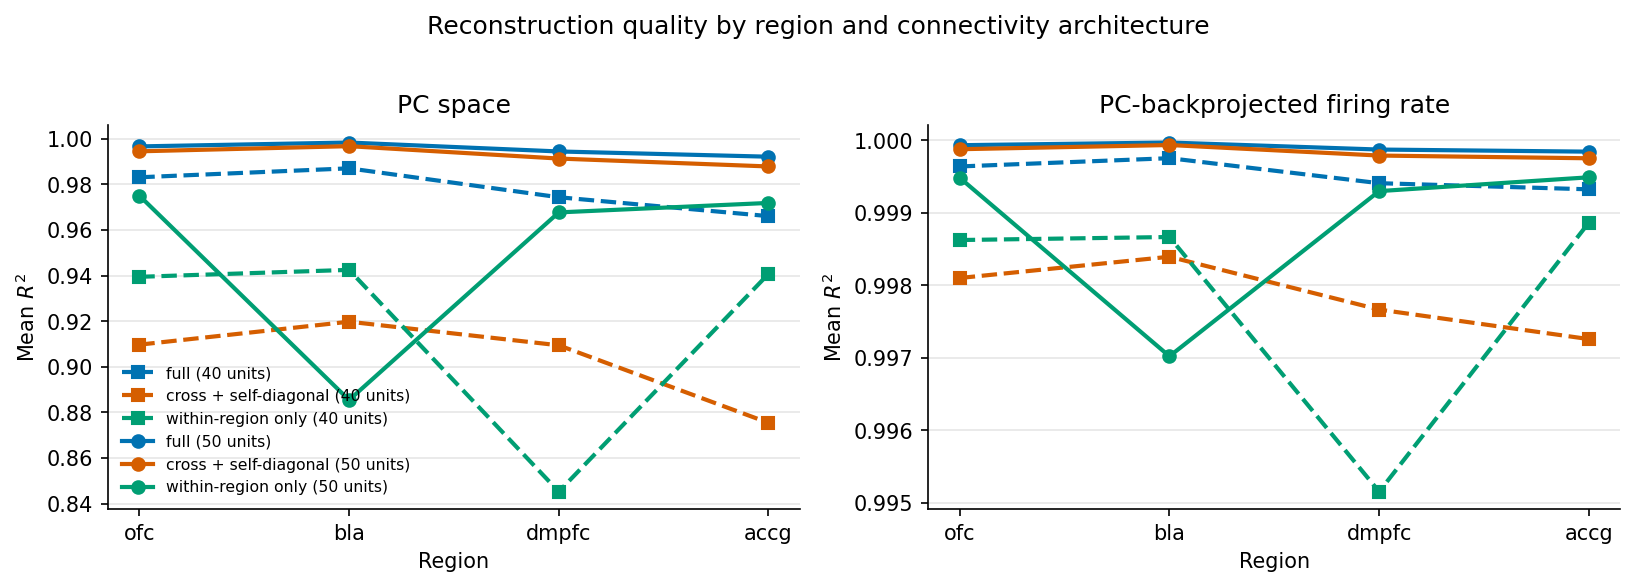

In [9]:
def architecture_of(label: str) -> str:
    return normalize_recurrent_connectivity(
        load_checkpoint(CONNECTIVITY_RUNS[label])["settings"]["recurrent_connectivity"]
    )


fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8), dpi=130)
for ax, space, title in zip(axes, ["region_pcs", "firing_rate"], ["PC space", "PC-backprojected firing rate"]):
    sub = per_region_metrics[per_region_metrics["space"] == space]
    grouped = sub.groupby(["label", "region"], sort=False)["r2"].mean().reset_index()
    for label in CONNECTIVITY_RUNS:
        arch = architecture_of(label)
        series = grouped[grouped["label"] == label]
        ax.plot(
            series["region"],
            series["r2"],
            marker="o" if label.startswith("h50") else "s",
            markersize=6,
            linewidth=2.0,
            linestyle="-" if label.startswith("h50") else "--",
            color=ARCH_COLORS[arch],
            label=f"{ARCH_LABELS[arch]} ({'50' if label.startswith('h50') else '40'} units)",
        )
    ax.set_title(title)
    ax.set_xlabel("Region")
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes:
    ax.set_ylabel("Mean $R^2$")
axes[0].legend(frameon=False, fontsize=7.5, loc="lower left")
fig.suptitle("Reconstruction quality by region and connectivity architecture", y=1.02)
fig.tight_layout()
display_figure(fig)

### 5a. Convergence check

A worse fit is only evidence about an architecture if the run actually converged. All six
runs used the same 50,000 iterations and the same learning rate, so the relevant question
is whether any of them was still improving (or oscillating) when training stopped.

,label,connectivity,iterations,final_loss,best_loss,final_over_best,rel_improvement_last_2k,loss_cv_last_2k
0,h40_full,full,50000,0.000242,0.000242,1.001583,0.044338,0.626987
1,h40_cross,cross_region_with_self_diagonal,50000,0.001123,0.000272,4.127378,-3.092857,0.937907
2,h40_within,within_region,50000,0.001079,0.000891,1.210760,0.301656,0.133938
3,h50_full,full,50000,0.000055,0.000050,1.094783,-0.025748,0.075008
4,h50_cross,cross_region_with_self_diagonal,50000,0.000088,0.000062,1.408182,0.118009,0.087708
5,h50_within,within_region,50000,0.001081,0.000389,2.777828,0.149056,0.068141


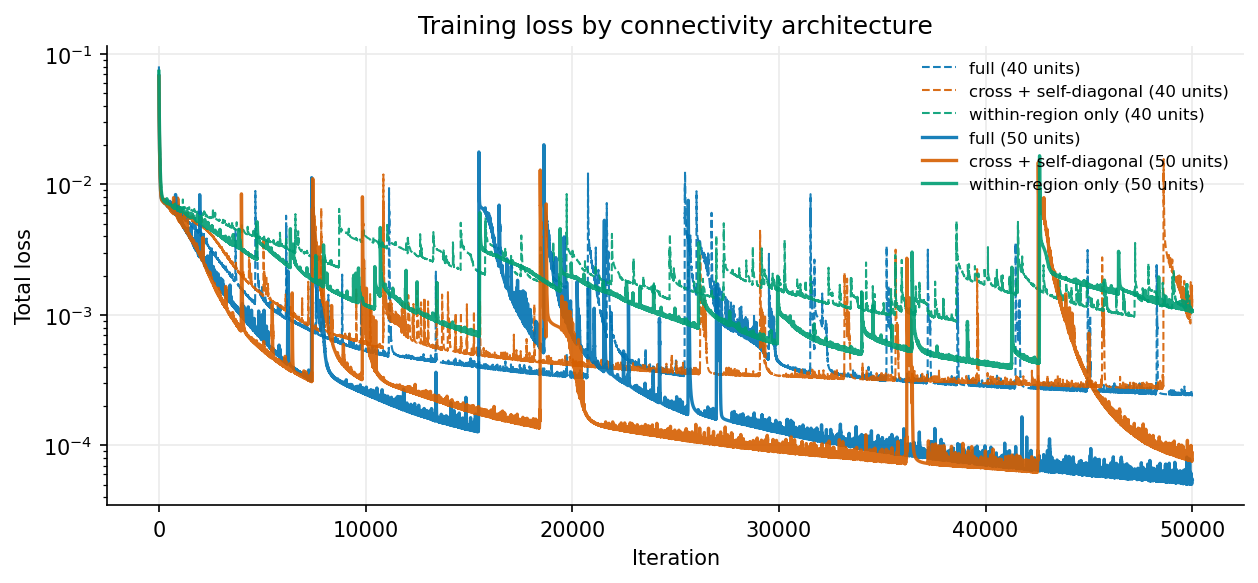

In [10]:
conv_rows = []
for label, run_id in CONNECTIVITY_RUNS.items():
    history = load_history(run_id)
    tail = history["loss"].to_numpy()[-2000:]
    conv_rows.append(
        {
            "label": label,
            "connectivity": architecture_of(label),
            "iterations": int(len(history)),
            "final_loss": float(history["loss"].iloc[-1]),
            "best_loss": float(history["loss"].min()),
            "final_over_best": float(history["loss"].iloc[-1] / history["loss"].min()),
            "rel_improvement_last_2k": float((tail[0] - tail[-1]) / tail[0]),
            "loss_cv_last_2k": float(np.std(tail) / np.mean(tail)),
        }
    )
display(pd.DataFrame(conv_rows))

fig, ax = plt.subplots(figsize=(8.5, 4.0), dpi=130)
for label, run_id in CONNECTIVITY_RUNS.items():
    history = load_history(run_id)
    arch = architecture_of(label)
    ax.plot(
        history["iteration"],
        history["loss"],
        color=ARCH_COLORS[arch],
        linewidth=1.6 if label.startswith("h50") else 1.0,
        linestyle="-" if label.startswith("h50") else "--",
        alpha=0.9,
        label=f"{ARCH_LABELS[arch]} ({'50' if label.startswith('h50') else '40'} units)",
    )
ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Total loss")
ax.set_title("Training loss by connectivity architecture")
ax.grid(color="0.92", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
display_figure(fig)

Read `final_over_best` and `rel_improvement_last_2k` before comparing architectures. A
`final_over_best` well above 1 means the saved checkpoint is *not* the best iterate the run
reached, and a negative `rel_improvement_last_2k` means the loss was rising over the last
2,000 iterations. At 40 units the `cross + self-diagonal` run ends about 4x above its own
best loss with a strongly negative tail slope: that point is a snapshot of an oscillating
optimizer, not a converged fit, and it should not be used to rank architectures. The 50-unit
runs are all within about 1.4x of their best iterate. Treat the 50-unit row as the
comparison and the 40-unit row as a capacity probe only.

This is a training-protocol problem, not an architecture result, and it is one more reason
the ensemble reruns in Section 10 are needed: the checkpoint should be the best iterate, and
the comparison should be over seeds.

## 6. Complexity-penalized in-sample criteria (and why they cannot decide this)

Treating the residuals as i.i.d. Gaussian with unknown variance gives the standard forms

$$\mathrm{AIC} = n\ln(\mathrm{RSS}/n) + 2(k+1),\qquad
\mathrm{BIC} = n\ln(\mathrm{RSS}/n) + (k+1)\ln n,\qquad
\mathrm{AICc} = \mathrm{AIC} + \frac{2k(k+1)}{n-k-1}.$$

`within_region` and `cross_region_with_self_diagonal` are both strictly nested inside
`full` at matched hidden size, so a nested F-test is also defined:

$$F = \frac{(\mathrm{RSS}_r-\mathrm{RSS}_f)/(k_f-k_r)}{\mathrm{RSS}_f/(n-k_f)}.$$

Read the residual degrees of freedom column before reading anything else in this table.

In [11]:
from scipy import stats


def information_criteria(rss: float, n: int, k: int) -> dict:
    aic = n * np.log(rss / n) + 2 * (k + 1)
    bic = n * np.log(rss / n) + (k + 1) * np.log(n)
    denom = n - k - 2
    aicc = aic + (2 * (k + 1) * (k + 2)) / denom if denom > 0 else np.nan
    return {"aic": aic, "bic": bic, "aicc": aicc, "residual_df": n - k}


ic_rows = []
for label in CONNECTIVITY_RUNS:
    fit = fit_table.set_index("label").loc[label]
    params = param_table.set_index("label").loc[label]
    row = {
        "label": label,
        "connectivity": params["connectivity"],
        "hidden_units": int(params["hidden_units_per_region"]),
        "k_effective": int(params["k_effective"]),
        "n": int(fit["n"]),
        "rss": float(fit["rss"]),
        "pooled_r2": float(fit["pooled_r2"]),
    }
    row.update(information_criteria(float(fit["rss"]), int(fit["n"]), int(params["k_effective"])))
    ic_rows.append(row)
ic_table = pd.DataFrame(ic_rows)
for column in ("aic", "bic"):
    for hidden in ic_table["hidden_units"].unique():
        selection = ic_table["hidden_units"] == hidden
        ic_table.loc[selection, f"delta_{column}"] = (
            ic_table.loc[selection, column] - ic_table.loc[selection, column].min()
        )
display(ic_table)

,label,connectivity,hidden_units,k_effective,n,rss,pooled_r2,aic,bic,aicc,residual_df,delta_aic,delta_bic
0,h40_full,full,40,33448,50400,8.799924,0.986324,-369213.371791,-73934.080649,-2.371934e+05,16952,0.000000,127873.340139
1,h40_cross,cross_region_with_self_diagonal,40,27208,50400,45.656305,0.929043,-298714.879028,-58520.725759,-2.348635e+05,23192,70498.492763,143286.695029
2,h40_within,within_region,40,14248,50400,43.052891,0.933089,-327593.980012,-201807.420789,-3.163603e+05,36152,41619.391779,0.000000
3,h50_full,full,50,49768,50400,1.586946,0.997534,-422905.134428,16442.978844,7.440597e+06,632,0.000000,156600.859003
4,h50_cross,cross_region_with_self_diagonal,50,39968,50400,2.836750,0.995591,-413230.407011,-60394.208989,-1.068908e+05,10432,9674.727417,79763.671170
5,h50_within,within_region,50,19768,50400,44.689498,0.930545,-314673.599810,-140157.880159,-2.891540e+05,30632,108231.534619,0.000000


In [12]:
lrt_rows = []
for hidden in (40, 50):
    full_label = f"h{hidden}_full"
    full_fit = fit_table.set_index("label").loc[full_label]
    full_k = int(param_table.set_index("label").loc[full_label, "k_effective"])
    n = int(full_fit["n"])
    for restricted_label in (f"h{hidden}_cross", f"h{hidden}_within"):
        restricted_fit = fit_table.set_index("label").loc[restricted_label]
        restricted_k = int(param_table.set_index("label").loc[restricted_label, "k_effective"])
        df_num = full_k - restricted_k
        df_den = n - full_k
        f_stat = (
            ((float(restricted_fit["rss"]) - float(full_fit["rss"])) / df_num) / (float(full_fit["rss"]) / df_den)
            if df_num > 0 and df_den > 0
            else np.nan
        )
        lrt_rows.append(
            {
                "restricted": restricted_label,
                "full": full_label,
                "delta_k": df_num,
                "residual_df_of_full": df_den,
                "rss_restricted": float(restricted_fit["rss"]),
                "rss_full": float(full_fit["rss"]),
                "F": f_stat,
                "p_value": float(stats.f.sf(f_stat, df_num, df_den)) if np.isfinite(f_stat) else np.nan,
            }
        )
display(pd.DataFrame(lrt_rows))

,restricted,full,delta_k,residual_df_of_full,rss_restricted,rss_full,F,p_value
0,h40_cross,h40_full,6240,16952,45.656305,8.799924,11.378110,0.0
1,h40_within,h40_full,19200,16952,43.052891,8.799924,3.436679,0.0
2,h50_cross,h50_full,9800,632,2.836750,1.586946,0.050789,1.0
3,h50_within,h50_full,30000,632,44.689498,1.586946,0.572185,1.0


**How to read Sections 6.** The residual degrees of freedom for the `full` models are a few
hundred out of 50,400 observations. Any p-value or AICc computed there is not
interpretable, and BIC's `k ln n` penalty is large enough to prefer the smallest model
almost regardless of fit. Report these numbers as a caveat, not as the selection
criterion. The next three sections do not depend on counting parameters this way.

## 7. Fit versus capacity

If `within_region` fits worse only because it is smaller, then plotting fit against
parameter count should place all three architectures on one common curve. If the
architectures lie on *separate* curves, the difference is structural, not budgetary.

The two available hidden sizes (40 and 50 units per region) give two points per
architecture. That is enough to see whether the curves are offset, but the parameter
ranges barely overlap — `within_region` at 50 units still has fewer parameters than
`full` at 40. The cell after the plot solves for the hidden sizes that would put all
three architectures on an identical parameter budget.

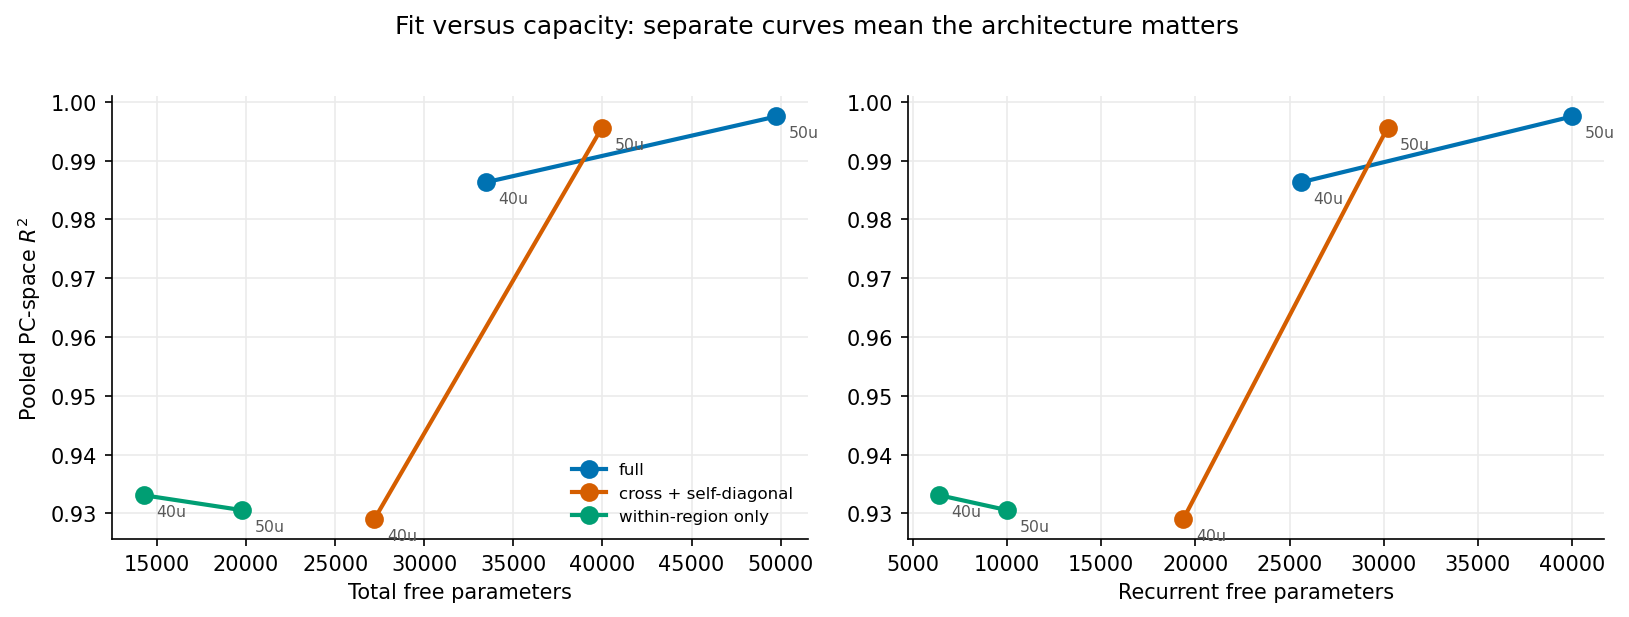

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), dpi=130)
merged = fit_table.merge(param_table[["label", "k_effective", "rec_within", "rec_cross_effective"]], on="label")
merged["rec_total"] = merged["rec_within"] + merged["rec_cross_effective"]

for ax, xcol, xlabel in zip(
    axes,
    ["k_effective", "rec_total"],
    ["Total free parameters", "Recurrent free parameters"],
):
    for arch in ARCH_ORDER:
        sub = merged[merged["connectivity"] == arch].sort_values(xcol)
        ax.plot(
            sub[xcol],
            sub["pooled_r2"],
            marker="o",
            markersize=8,
            linewidth=2.0,
            color=ARCH_COLORS[arch],
            label=ARCH_LABELS[arch],
        )
        for _, row in sub.iterrows():
            ax.annotate(
                f"{int(row['hidden_units'])}u",
                (row[xcol], row["pooled_r2"]),
                textcoords="offset points",
                xytext=(6, -10),
                fontsize=7.5,
                color="0.35",
            )
    ax.set_xlabel(xlabel)
    ax.grid(color="0.92", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Pooled PC-space $R^2$")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("Fit versus capacity: separate curves mean the architecture matters", y=1.02)
fig.tight_layout()
display_figure(fig)

In [14]:
def total_parameters_for(
    connectivity: str,
    hidden_units: int,
    *,
    n_regions: int = 4,
    n_pcs: int = 42,
    input_dim: int = 3,
    n_conditions: int = 3,
    bottleneck_dim: int | None = None,
) -> dict:
    """Analytic parameter count for a hypothetical run, matching count_run_parameters."""
    mode = normalize_recurrent_connectivity(connectivity)
    total_units = n_regions * hidden_units
    if mode == "within_region":
        within = n_regions * hidden_units**2
        cross = 0
    elif mode == "cross_region_with_self_diagonal":
        within = n_regions * hidden_units
        cross_pairs = n_regions * (n_regions - 1)
        cross = cross_pairs * (
            hidden_units**2
            if bottleneck_dim is None
            else bottleneck_dim * (2 * hidden_units - bottleneck_dim)
        )
    else:
        within = n_regions * hidden_units**2
        cross_pairs = n_regions * (n_regions - 1)
        cross = cross_pairs * (
            hidden_units**2
            if bottleneck_dim is None
            else bottleneck_dim * (2 * hidden_units - bottleneck_dim)
        )
    input_params = total_units * input_dim
    readout = n_regions * (n_pcs * hidden_units + n_pcs)
    initial_state = n_conditions * total_units
    return {
        "rec_within": within,
        "rec_cross": cross,
        "input": input_params,
        "readout": readout,
        "initial_state": initial_state,
        "k_effective": within + cross + input_params + readout + initial_state,
    }


def hidden_units_for_budget(connectivity: str, budget: int, *, bottleneck_dim: int | None = None, **kwargs) -> int:
    """Smallest hidden size whose parameter count is closest to the budget."""
    candidates = range(2, 2000)
    return min(
        candidates,
        key=lambda h: abs(total_parameters_for(connectivity, h, bottleneck_dim=bottleneck_dim, **kwargs)["k_effective"] - budget),
    )


reference_budget = int(param_table.set_index("label").loc["h50_full", "k_effective"])
matched = []
for arch in ARCH_ORDER:
    hidden = hidden_units_for_budget(arch, reference_budget)
    counts = total_parameters_for(arch, hidden)
    matched.append(
        {
            "connectivity": arch,
            "matched_hidden_units": hidden,
            "k_effective": counts["k_effective"],
            "budget": reference_budget,
            "pct_of_budget": 100.0 * counts["k_effective"] / reference_budget,
            "rec_within": counts["rec_within"],
            "rec_cross": counts["rec_cross"],
        }
    )
print(f"Reference budget = h50 `full` total free parameters = {reference_budget}")
display(pd.DataFrame(matched))

Reference budget = h50 `full` total free parameters = 49768


,connectivity,matched_hidden_units,k_effective,budget,pct_of_budget,rec_within,rec_cross
0,full,50,49768,49768,100.000000,10000,30000
1,cross_region_with_self_diagonal,57,50328,49768,101.125221,228,38988
2,within_region,90,49848,49768,100.160746,32400,0


Those three hidden sizes are the configuration for the capacity-matched run in Section 10.
Under that design, any remaining gap cannot be attributed to parameter count.

## 8. Ablation inside the trained `full` model

This comparison needs no parameter accounting at all. Take the *one* fitted `full` model
and delete groups of recurrent connections at replay time, without refitting. The drop in
R^2 measures how much the fitted solution actually routes through those connections.

Two caveats worth stating with the result: ablation measures reliance of *this* solution,
not what a model retrained without those connections could achieve (Section 5 gives that,
and Section 10 gives the capacity-matched version); and because the weights are not
retrained, ablation is an upper bound on the damage.

**Why the lesioned R^2 values are negative.** $R^2 = 1 - \mathrm{SS}_{res}/\mathrm{SS}_{tot}$
is confined to $[0, 1]$ only when the predictor is the least-squares fit *to the data it is
being scored on*. A lesioned network is not fit to anything — its weights were optimized for
a different (intact) model — so it is an arbitrary predictor, and $\mathrm{SS}_{res}$ can
exceed $\mathrm{SS}_{tot}$ without bound. $R^2 = -1$ simply means the lesioned model's
squared error is twice that of predicting each region's grand mean.

The diagnostic table below separates the two ways that can happen: the trajectories could
blow up (large `prediction_amplitude`) or stay bounded but take the wrong shape
(`prediction_amplitude` at or below the target's, with `pooled_correlation` collapsing). It
also reports $\mathrm{SS}_{res}/\mathrm{SS}_{tot}$ directly, so the arithmetic behind each
$R^2$ is visible.

In [15]:
ABLATION_RUN = "h50_full"
run_id = CONNECTIVITY_RUNS[ABLATION_RUN]
regions = list(load_checkpoint(run_id)["model_spec"]["region_order"])
cross_pairs = [(s, t) for s in regions for t in regions if s != t]
within_pairs = [(r, r) for r in regions]

ablation_sets = {
    "none (intact)": (),
    "all cross-region": tuple(cross_pairs),
    "all within-region": tuple(within_pairs),
}
for source, target in cross_pairs:
    ablation_sets[f"{source} -> {target}"] = ((source, target),)
for region in regions:
    # Same "source -> target" naming as the cross-region lesions, so the grid below
    # shows within-region blocks on its diagonal rather than leaving it empty.
    ablation_sets[f"{region} -> {region}"] = ((region, region),)

baseline = None
ablation_rows = []
for name, blocks in ablation_sets.items():
    replay = replay_run(run_id, zero_blocks=blocks)
    metrics = pooled_fit_metrics(replay)
    if baseline is None:
        baseline = metrics["pooled_r2"]
    ablation_rows.append(
        {
            "ablation": name,
            "n_blocks": len(blocks),
            "pooled_r2": metrics["pooled_r2"],
            "delta_r2": metrics["pooled_r2"] - baseline,
            "rss_over_tss": metrics["rss_over_tss"],
            "pooled_correlation": metrics["pooled_correlation"],
            "prediction_amplitude": metrics["prediction_amplitude"],
            "mse": metrics["mse"],
            "mse_ratio_to_intact": metrics["mse"] / ablation_rows[0]["mse"] if ablation_rows else 1.0,
        }
    )
ablation_table = pd.DataFrame(ablation_rows)
display(ablation_table)

,ablation,n_blocks,pooled_r2,delta_r2,rss_over_tss,pooled_correlation,prediction_amplitude,mse,mse_ratio_to_intact
0,none (intact),0,0.997534,0.000000,0.002466,0.998766,1.077421,0.000031,1.000000
1,all cross-region,12,-0.651269,-1.648802,1.651269,0.265176,0.479341,0.021081,669.515306
2,all within-region,4,-2.282027,-3.279561,3.282027,0.278510,0.962505,0.041900,1330.714599
3,ofc -> bla,1,-1.092790,-2.090324,2.092790,0.314087,0.800518,0.026718,848.532487
4,ofc -> dmpfc,1,-0.813080,-1.810614,1.813080,0.415091,1.006516,0.023147,735.122601
5,ofc -> accg,1,-1.148822,-2.146356,2.148822,0.355443,0.979534,0.027433,871.250911
6,bla -> ofc,1,-1.287950,-2.285483,2.287950,0.294132,0.839300,0.029209,927.660923
7,bla -> dmpfc,1,-0.902406,-1.899940,1.902406,0.355299,0.814770,0.024287,771.340171
8,bla -> accg,1,-0.903560,-1.901094,1.903560,0.356249,0.841886,0.024302,771.808213
9,dmpfc -> ofc,1,-1.005648,-2.003181,2.005648,0.362256,0.834061,0.025605,813.200038


In [16]:
diagnostic = ablation_table[
    ["ablation", "pooled_r2", "rss_over_tss", "pooled_correlation", "prediction_amplitude"]
].copy()
diagnostic["target_amplitude"] = pooled_fit_metrics(replay_run(run_id))["target_amplitude"]
diagnostic["r2_recomputed_from_ratio"] = 1.0 - diagnostic["rss_over_tss"]
display(diagnostic)

,ablation,pooled_r2,rss_over_tss,pooled_correlation,prediction_amplitude,target_amplitude,r2_recomputed_from_ratio
0,none (intact),0.997534,0.002466,0.998766,1.077421,1.078071,0.997534
1,all cross-region,-0.651269,1.651269,0.265176,0.479341,1.078071,-0.651269
2,all within-region,-2.282027,3.282027,0.278510,0.962505,1.078071,-2.282027
3,ofc -> bla,-1.092790,2.092790,0.314087,0.800518,1.078071,-1.092790
4,ofc -> dmpfc,-0.813080,1.813080,0.415091,1.006516,1.078071,-0.813080
5,ofc -> accg,-1.148822,2.148822,0.355443,0.979534,1.078071,-1.148822
6,bla -> ofc,-1.287950,2.287950,0.294132,0.839300,1.078071,-1.287950
7,bla -> dmpfc,-0.902406,1.902406,0.355299,0.814770,1.078071,-0.902406
8,bla -> accg,-0.903560,1.903560,0.356249,0.841886,1.078071,-0.903560
9,dmpfc -> ofc,-1.005648,2.005648,0.362256,0.834061,1.078071,-1.005648


`r2_recomputed_from_ratio` reproduces `pooled_r2` exactly, which is the arithmetic check.
The lesioned predictions do **not** diverge — their amplitude is at or below the target's —
so the negative values come from bounded trajectories of the wrong shape, not from numerical
blow-up. `pooled_correlation` is the bounded companion metric and is the one to read once
$R^2$ has gone negative.

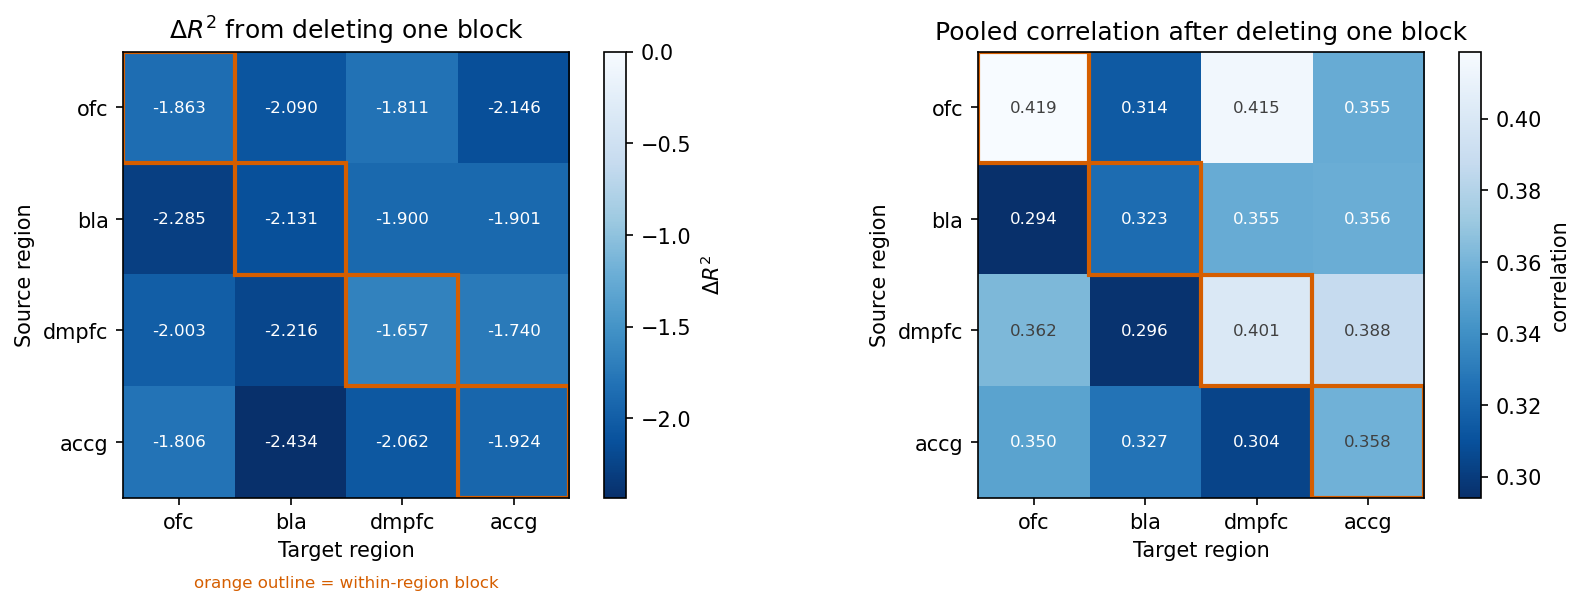

In [17]:
pairwise = ablation_table[ablation_table["ablation"].str.contains("->")].copy()
pairwise["source"] = pairwise["ablation"].str.split(" -> ").str[0]
pairwise["target"] = pairwise["ablation"].str.split(" -> ").str[1]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), dpi=130)


def draw_block_grid(ax, value_column, title, colorbar_label, *, sequential_low_is_bad):
    """Draw the 4x4 source-by-target lesion grid, diagonal = within-region blocks."""
    grid = (
        pairwise.pivot(index="source", columns="target", values=value_column)
        .reindex(index=regions, columns=regions)
    )
    values = grid.to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    if sequential_low_is_bad:
        vmin, vmax = float(np.nanmin(finite)), 0.0
    else:
        vmin, vmax = float(np.nanmin(finite)), float(np.nanmax(finite))
    image = ax.imshow(values, cmap="Blues_r", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(regions)), regions)
    ax.set_yticks(range(len(regions)), regions)
    ax.set_xlabel("Target region")
    ax.set_ylabel("Source region")
    ax.set_title(title)
    span = vmax - vmin
    for i in range(len(regions)):
        for j in range(len(regions)):
            value = values[i, j]
            if not np.isfinite(value):
                continue
            is_dark = span > 0 and (value - vmin) < 0.5 * span
            ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8,
                    color="white" if is_dark else "0.25")
    # Mark the diagonal: those are within-region blocks, not inter-regional ones.
    for i in range(len(regions)):
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False,
                                   edgecolor="#D55E00", linewidth=2.0))
    fig.colorbar(image, ax=ax, fraction=0.046, label=colorbar_label)


draw_block_grid(
    axes[0],
    "delta_r2",
    "$\\Delta R^2$ from deleting one block",
    "$\\Delta R^2$",
    sequential_low_is_bad=True,
)
draw_block_grid(
    axes[1],
    "pooled_correlation",
    "Pooled correlation after deleting one block",
    "correlation",
    sequential_low_is_bad=False,
)
axes[0].text(0.5, -0.20, "orange outline = within-region block", transform=axes[0].transAxes,
             ha="center", fontsize=8, color="#D55E00")

fig.tight_layout()
display_figure(fig)

**These lesions saturate, and that is itself the finding.** Deleting *any* single one of the
sixteen blocks — the twelve cross-region blocks on the off-diagonal or the four within-region
blocks on the diagonal — drops pooled R^2 from ~0.998 to roughly -2, and deleting all twelve
cross blocks together is no worse than deleting one. Once a block is removed the recurrent
dynamics leave the regime the readouts were fit for, and R^2 stops grading the damage.

The interpretable statement is therefore qualitative but strong: the fitted `full` solution
is **not decomposable**. There is no subset of connections the fit merely decorates with;
inter-regional coupling is load-bearing in the same way the internal blocks are. What the
saturated numbers cannot support is a *ranking* of individual pathways — the apparent
ordering of the sixteen blocks in the table above is not meaningful at this lesion depth,
and the correlation panel makes that concrete by showing every lesion landing in the same
narrow band.

To recover a graded measure, scale a block group by a factor between 0 and 1 instead of
zeroing it. The dose-response curve below shows where each group's contribution starts to
matter, and is comparable across groups because both are measured on the same intact model.

group,cross-region,within-region
scale,,
1.00,0.997534,0.997534
0.95,0.911740,0.959469
0.90,0.681385,0.822329
0.80,0.326021,0.442493
0.60,0.039029,-0.077106
0.40,-0.176355,-0.626919
0.20,-0.392420,-1.311332
0.00,-0.651269,-2.282027


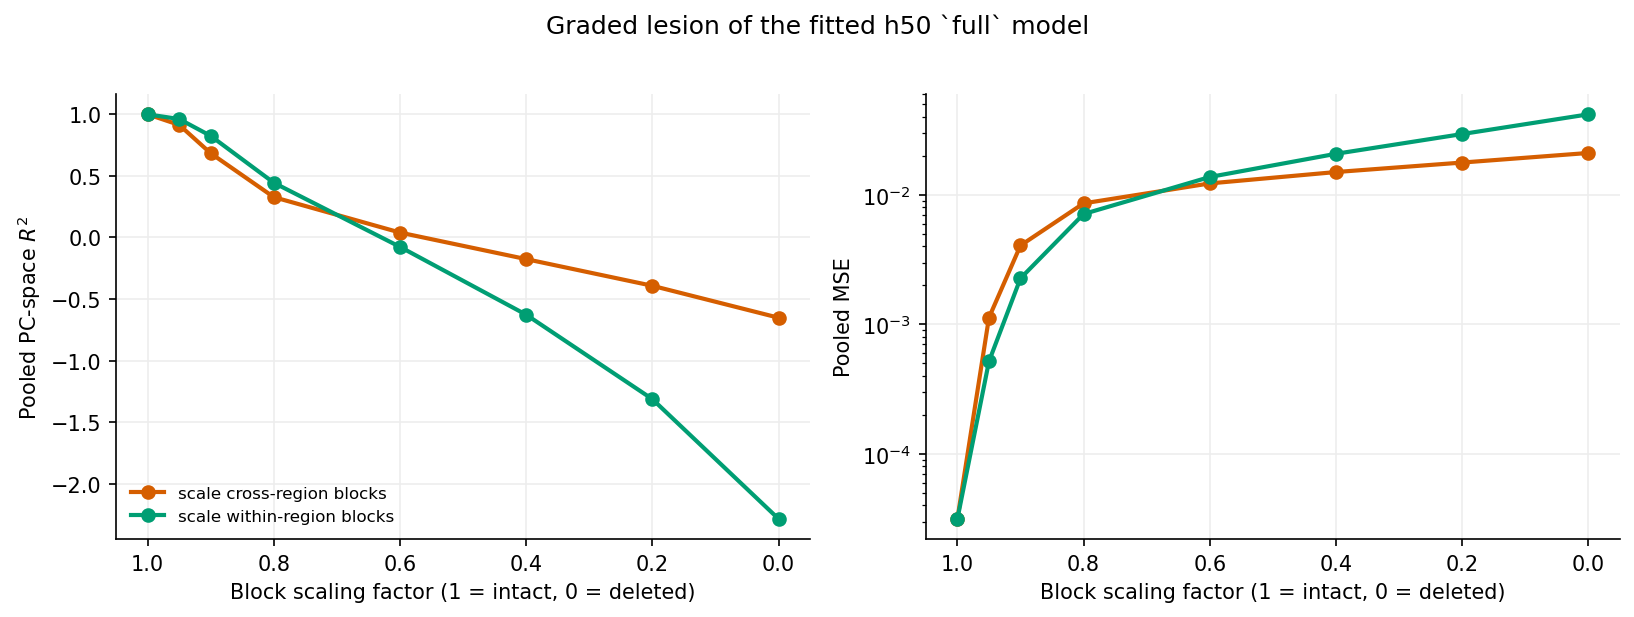

In [18]:
scale_grid = [1.0, 0.95, 0.9, 0.8, 0.6, 0.4, 0.2, 0.0]
dose_rows = []
for group_name, pairs in (("cross-region", cross_pairs), ("within-region", within_pairs)):
    for factor in scale_grid:
        replay = replay_run(run_id, scale_blocks={pair: factor for pair in pairs})
        metrics = pooled_fit_metrics(replay)
        dose_rows.append(
            {
                "group": group_name,
                "scale": factor,
                "pooled_r2": metrics["pooled_r2"],
                "mse": metrics["mse"],
            }
        )
dose_table = pd.DataFrame(dose_rows)
display(dose_table.pivot(index="scale", columns="group", values="pooled_r2").sort_index(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), dpi=130)
group_colors = {
    "cross-region": ARCH_COLORS["cross_region_with_self_diagonal"],
    "within-region": ARCH_COLORS["within_region"],
}
for group_name, sub in dose_table.groupby("group", sort=False):
    sub = sub.sort_values("scale")
    axes[0].plot(sub["scale"], sub["pooled_r2"], marker="o", markersize=6, linewidth=2.0,
                 color=group_colors[group_name], label=f"scale {group_name} blocks")
    axes[1].plot(sub["scale"], sub["mse"], marker="o", markersize=6, linewidth=2.0,
                 color=group_colors[group_name], label=f"scale {group_name} blocks")
axes[0].set_ylabel("Pooled PC-space $R^2$")
axes[1].set_ylabel("Pooled MSE")
axes[1].set_yscale("log")
for ax in axes:
    ax.set_xlabel("Block scaling factor (1 = intact, 0 = deleted)")
    ax.invert_xaxis()
    ax.grid(color="0.93", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle("Graded lesion of the fitted h50 `full` model", y=1.02)
fig.tight_layout()
display_figure(fig)

### 8a. Do within-region and inter-regional blocks differ in lesion impact?

Each of the sixteen single-block lesions removes exactly the same amount of the model: in
the `full` architecture every block is a dense 50 x 50 matrix, so all sixteen carry 2,500
weights. That makes this the one comparison in the notebook that needs no parameter
correction at all — the groups differ in *what* the weights connect, not how many there are.
That gives 4 within-region blocks against 12 inter-regional ones.

Each block is perturbed at two depths, because the choice of depth turns out to matter:

- **Deletion** (scale 0). This is the lesion from the grid above, and it lands in the
  saturated regime — every block, of either type, drives R^2 to roughly -2. Group
  differences measured here are differences between saturated values.
- **Graded attenuation** (scale 0.9). Mild enough that R^2 stays around 0.95-0.97, so the
  metric is still grading damage rather than reporting collapse. This is the comparison to
  trust.

With group sizes this small the appropriate test is the exact Mann-Whitney U rank-sum test,
reported with Welch's t-test as a parametric companion and two effect sizes (Hedges' g and
Cliff's delta).

**What this tests, and what it does not.** The sixteen lesions are perturbations of one
fitted network, not sixteen independent experiments, and there is a single seed behind all
of them. A result here says the within-region and inter-regional blocks of *this* solution
are differently load-bearing; it does not generalize to the architecture or to the
data-generating process. A claim of that kind needs the multi-seed ensemble from Section 10,
where each seed contributes one independent estimate of the group difference.

In [19]:
from math import comb

from scipy import stats

intact = pooled_fit_metrics(replay_run(run_id))
all_blocks = [(source, target) for source in regions for target in regions]


def single_block_effects(scale: float) -> pd.DataFrame:
    """Perturb each block on its own by ``scale`` and score the whole model."""
    rows = []
    for source, target in all_blocks:
        replay = replay_run(run_id, scale_blocks={(source, target): scale})
        metrics = pooled_fit_metrics(replay)
        rows.append(
            {
                "block": f"{source} -> {target}",
                "source": source,
                "target": target,
                "group": "within-region" if source == target else "cross-region",
                "scale": scale,
                "pooled_r2": metrics["pooled_r2"],
                "pooled_correlation": metrics["pooled_correlation"],
                "delta_r2": metrics["pooled_r2"] - intact["pooled_r2"],
                "delta_correlation": metrics["pooled_correlation"] - intact["pooled_correlation"],
            }
        )
    return pd.DataFrame(rows)


LESION_DEPTHS = {"deletion (scale 0)": 0.0, "graded (scale 0.9)": 0.9}
block_effects = pd.concat(
    [single_block_effects(scale).assign(depth=name) for name, scale in LESION_DEPTHS.items()],
    ignore_index=True,
)
display(
    block_effects.pivot(index="block", columns="depth", values=["delta_r2", "delta_correlation"]).round(4)
)

delta_r2                     delta_correlation                   
depth          deletion (scale 0) graded (scale 0.9) deletion (scale 0) graded (scale 0.9)
block                                                                                     
accg -> accg              -1.9242            -0.0387            -0.6404            -0.0195
accg -> bla               -2.4342            -0.0391            -0.6721            -0.0197
accg -> dmpfc             -2.0623            -0.0238            -0.6945            -0.0120
accg -> ofc               -1.8059            -0.0287            -0.6483            -0.0144
bla -> accg               -1.9011            -0.0265            -0.6425            -0.0133
bla -> bla                -2.1308            -0.0452            -0.6759            -0.0228
bla -> dmpfc              -1.8999            -0.0254            -0.6435            -0.0127
bla -> ofc                -2.2855            -0.0347            -0.7046            -0.0175
dmpfc -> accg             -1.7396            -0.0260            -0.6108            -0.0131
dmpfc -> bla              -2.2157            -0.0345            -0.7029            -0.0174
dmpfc -> dmpfc            -1.6567            -0.0407            -0.5979            -0.0206
dmpfc -> ofc              -2.0032            -0.0361            -0.6365            -0.0181
ofc -> accg               -2.1464            -0.0292            -0.6433            -0.0146
ofc -> bla                -2.0903            -0.0311            -0.6847            -0.0157
ofc -> dmpfc              -1.8106            -0.0314            -0.5837            -0.0157
ofc -> ofc                -1.8631            -0.0479            -0.5800            -0.0239

In [20]:
def hedges_g(a, b) -> float:
    """Standardized mean difference with the small-sample bias correction."""
    n_a, n_b = len(a), len(b)
    pooled_sd = np.sqrt(
        ((n_a - 1) * np.var(a, ddof=1) + (n_b - 1) * np.var(b, ddof=1)) / (n_a + n_b - 2)
    )
    if pooled_sd == 0:
        return np.nan
    correction = 1.0 - 3.0 / (4.0 * (n_a + n_b) - 9.0)
    return float((np.mean(a) - np.mean(b)) / pooled_sd * correction)


def cliffs_delta(a, b) -> float:
    """Non-parametric effect size: P(a > b) - P(a < b)."""
    return float(np.sign(np.subtract.outer(np.asarray(a), np.asarray(b))).mean())


stat_rows = []
for depth in LESION_DEPTHS:
    for metric, pretty in (("delta_r2", "delta R2"), ("delta_correlation", "delta correlation")):
        subset = block_effects[block_effects["depth"] == depth]
        within = subset.loc[subset["group"] == "within-region", metric].to_numpy()
        cross = subset.loc[subset["group"] == "cross-region", metric].to_numpy()
        u_stat, u_p = stats.mannwhitneyu(within, cross, alternative="two-sided", method="exact")
        t_stat, t_p = stats.ttest_ind(within, cross, equal_var=False)
        stat_rows.append(
            {
                "depth": depth,
                "metric": pretty,
                "n_within": len(within),
                "n_cross": len(cross),
                "mean_within": float(np.mean(within)),
                "mean_cross": float(np.mean(cross)),
                "sd_within": float(np.std(within, ddof=1)),
                "sd_cross": float(np.std(cross, ddof=1)),
                "mean_difference": float(np.mean(within) - np.mean(cross)),
                "mannwhitney_u": float(u_stat),
                "mannwhitney_p_exact": float(u_p),
                "welch_t": float(t_stat),
                "welch_p": float(t_p),
                "hedges_g": hedges_g(within, cross),
                "cliffs_delta": cliffs_delta(within, cross),
            }
        )
group_stats = pd.DataFrame(stat_rows)
display(group_stats)

n_within_blocks = int(group_stats["n_within"].iloc[0])
n_blocks_total = n_within_blocks + int(group_stats["n_cross"].iloc[0])
print(
    f"Exact test floor with n={n_within_blocks} vs n={n_blocks_total - n_within_blocks}: "
    f"the smallest two-sided p attainable is {2.0 / comb(n_blocks_total, n_within_blocks):.4f}. "
    "A null result at this sample size is not evidence of no difference."
)

,depth,metric,n_within,n_cross,mean_within,mean_cross,sd_within,sd_cross,mean_difference,mannwhitney_u,mannwhitney_p_exact,welch_t,welch_p,hedges_g,cliffs_delta
0,deletion (scale 0),delta R2,4,12,-1.893714,-2.032892,0.195157,0.212811,0.139178,32.0,0.379121,1.207026,0.275846,0.629140,0.333333
1,deletion (scale 0),delta correlation,4,12,-0.623566,-0.655619,0.043124,0.037353,0.032053,36.0,0.170330,1.329569,0.245651,0.783837,0.500000
2,graded (scale 0.9),delta R2,4,12,-0.043122,-0.030546,0.004184,0.004808,-0.012576,1.0,0.002198,-5.009530,0.002536,-2.539813,-0.958333
3,graded (scale 0.9),delta correlation,4,12,-0.021682,-0.015351,0.002005,0.002418,-0.006331,1.0,0.002198,-5.183018,0.001841,-2.563079,-0.958333


Exact test floor with n=4 vs n=12: the smallest two-sided p attainable is 0.0011. A null result at this sample size is not evidence of no difference.


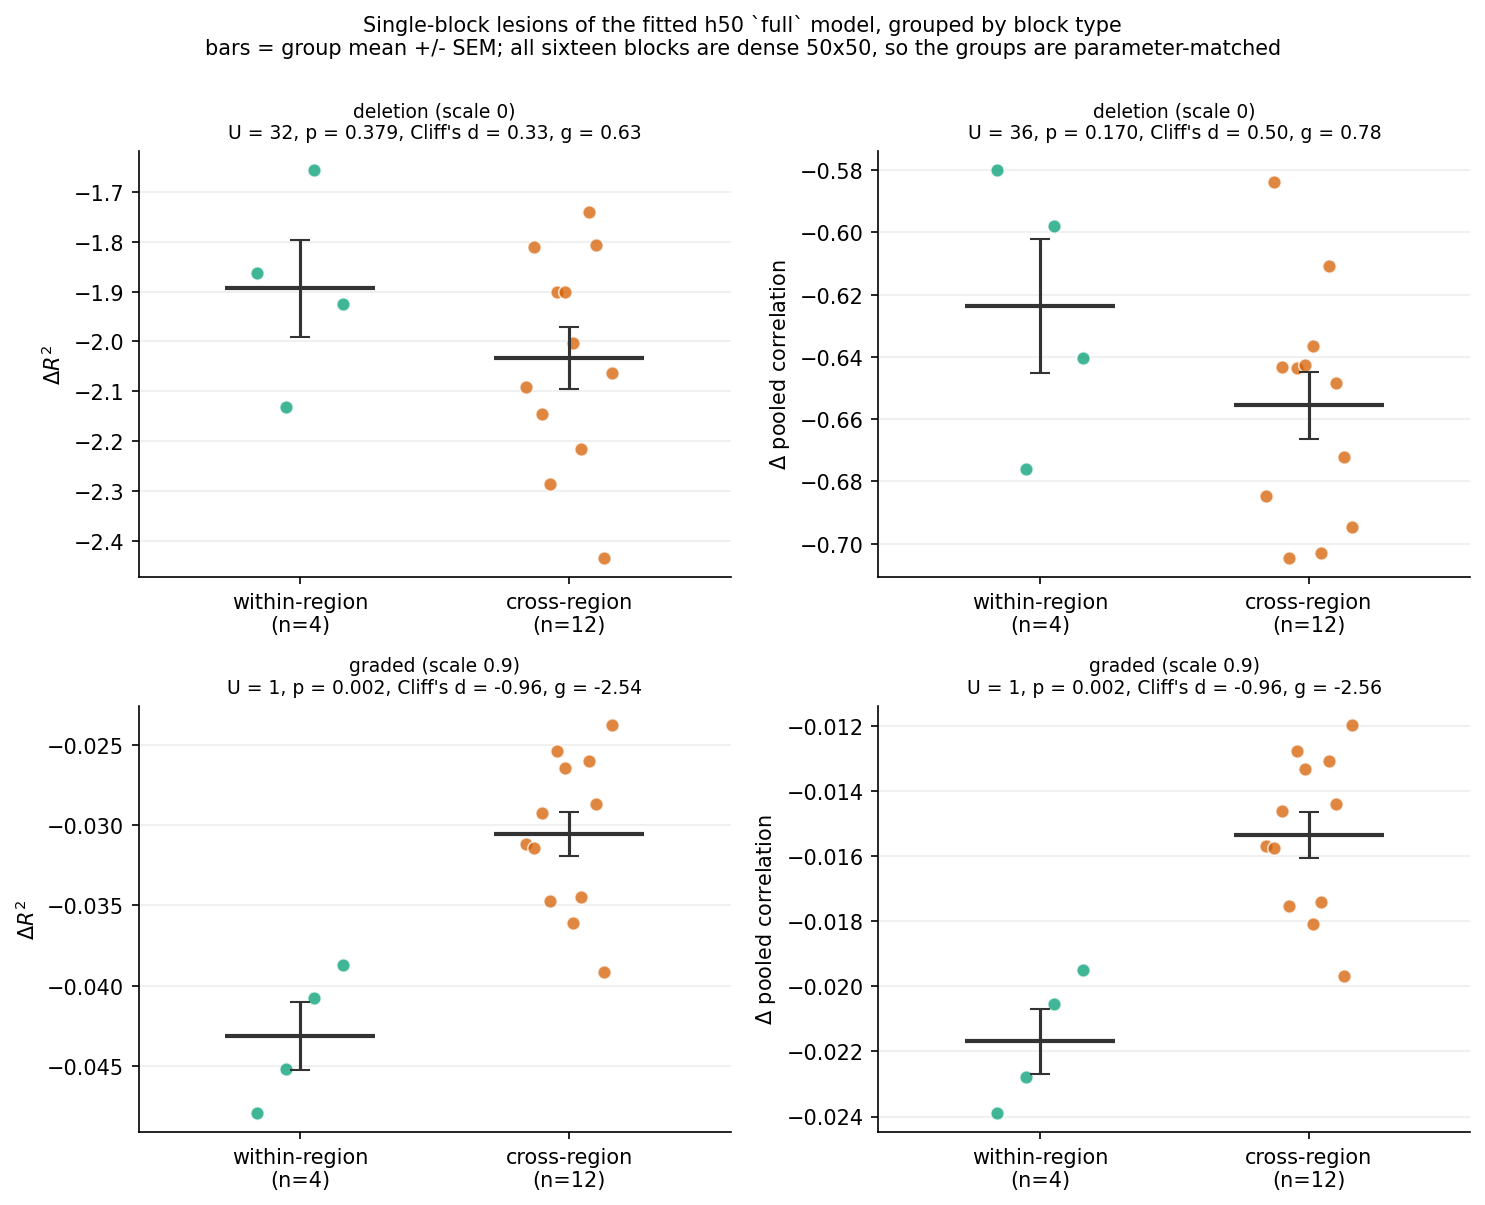

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(10.0, 8.0), dpi=130)
group_order = ["within-region", "cross-region"]
block_group_colors = {
    "within-region": ARCH_COLORS["within_region"],
    "cross-region": ARCH_COLORS["cross_region_with_self_diagonal"],
}

for row_idx, depth in enumerate(LESION_DEPTHS):
    subset = block_effects[block_effects["depth"] == depth]
    for col_idx, (metric, pretty) in enumerate(
        (("delta_r2", "$\\Delta R^2$"), ("delta_correlation", "$\\Delta$ pooled correlation"))
    ):
        ax = axes[row_idx, col_idx]
        for position, group_name in enumerate(group_order):
            values = subset.loc[subset["group"] == group_name, metric].to_numpy()
            # Deterministic spread instead of random jitter, so the figure is reproducible.
            offsets = np.linspace(-0.16, 0.16, len(values)) if len(values) > 1 else np.zeros(1)
            ax.scatter(position + offsets, values, s=42, color=block_group_colors[group_name],
                       alpha=0.75, edgecolor="white", linewidth=0.8, zorder=3)
            mean = float(np.mean(values))
            ax.hlines(mean, position - 0.28, position + 0.28, color="0.2", linewidth=2.0, zorder=4)
            ax.errorbar(position, mean, yerr=float(stats.sem(values)), color="0.2",
                        capsize=5, linewidth=1.5, zorder=4)
        row = group_stats[(group_stats["depth"] == depth) & (group_stats["metric"].str.endswith(
            "R2" if metric == "delta_r2" else "correlation"))].iloc[0]
        ax.set_xticks(
            range(len(group_order)),
            [f"{name}\n(n={int(row['n_within'] if name == 'within-region' else row['n_cross'])})"
             for name in group_order],
        )
        ax.set_ylabel(pretty)
        ax.set_title(
            f"{depth}\nU = {row['mannwhitney_u']:.0f}, p = {row['mannwhitney_p_exact']:.3f}, "
            f"Cliff's d = {row['cliffs_delta']:.2f}, g = {row['hedges_g']:.2f}",
            fontsize=9,
        )
        ax.set_xlim(-0.6, 1.6)
        ax.grid(axis="y", color="0.93", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Single-block lesions of the fitted h50 `full` model, grouped by block type\n"
    "bars = group mean +/- SEM; all sixteen blocks are dense 50x50, so the groups are parameter-matched",
    y=1.0,
    fontsize=10,
)
fig.tight_layout()
display_figure(fig)

**Reading the two depths together.** At deletion depth the two groups are
indistinguishable, which is what saturation looks like: every block, of either type, has
already pushed the model past the point where R^2 grades anything, so the comparison is
between values pinned near a floor. Do not report that null as a finding — the test simply
has no signal to work with there.

At graded depth the metric is live again, and the ordering is consistent across both
measures and nearly perfectly separated: attenuating a *within-region* block by 10% costs
more than attenuating an inter-regional block by the same factor, with the rank-sum
statistic landing one step off the floor the exact test can reach at these group sizes and
Cliff's delta near -1. Read the effect size rather than the p-value here — with a p-value
this close to the attainable minimum, the test is reporting clean separation, not strength
of evidence, and sixteen perturbations of one network make this a descriptive statement
about this fit rather than an inferential one about the architecture.

The direction is worth holding onto because it cuts against the grouped result in Section 8,
where deleting all four within-region blocks was more damaging than deleting all twelve
cross-region blocks. Both point the same way — internal coupling carries more weight per
block in this solution — but neither says inter-regional coupling is dispensable. Section 5
already settled that: a model trained *without* cross-region blocks tops out near R^2 0.93,
while one trained without dense internal blocks reaches 0.996.

The dose-response is steep in both directions: a 5% attenuation already costs several
points of R^2, and by 20% attenuation the fit is gone. The model is a finely tuned
dynamical system, not a robust one — worth remembering before reading any perturbation
result from these fits as a claim about the brain.

Comparing the two curves, attenuating the cross-region blocks costs *more* at mild
perturbation than attenuating the within-region blocks, which reverses the ordering the
saturated deletions suggested. One asymmetry to keep in view: the scaling is applied to 12
cross blocks versus 4 internal blocks (30,000 versus 10,000 weights in this model), so the
cross-region curve reflects a larger perturbation of the recurrent matrix. The curves
establish that inter-regional coupling is at least as load-bearing as internal coupling;
they do not cleanly rank the two.

## 9. Effective rank of the learned inter-regional blocks

The `full` model was free to use full-rank inter-regional coupling. What rank did it
actually use? The singular spectrum of each fitted cross-region block answers that, and it
is the quantity that predicts how far the explicit bottleneck of Part 2 can be pushed
before it starts removing something the unconstrained fit was using.

In [22]:
rank_table = pd.concat(
    [inter_regional_block_ranks(CONNECTIVITY_RUNS[label]).assign(label=label) for label in ("h50_full", "h50_cross")],
    ignore_index=True,
)
display(rank_table[["label", "source", "target", "numerical_rank", "participation_ratio", "n_sv_for_90pct_energy", "frobenius_norm"]])

,label,source,target,numerical_rank,participation_ratio,n_sv_for_90pct_energy,frobenius_norm
0,h50_full,ofc,bla,50,25.046386,26,4.072793
1,h50_full,ofc,dmpfc,50,25.491389,26,4.107127
2,h50_full,ofc,accg,50,24.962622,26,4.069934
3,h50_full,bla,ofc,50,24.862435,26,4.006401
4,h50_full,bla,dmpfc,50,25.625314,26,4.025985
5,h50_full,bla,accg,50,25.270833,26,4.009972
6,h50_full,dmpfc,ofc,50,24.501757,25,4.100550
7,h50_full,dmpfc,bla,50,24.981419,26,4.103499
8,h50_full,dmpfc,accg,50,26.011028,27,4.024187
9,h50_full,accg,ofc,50,25.071874,26,4.043069


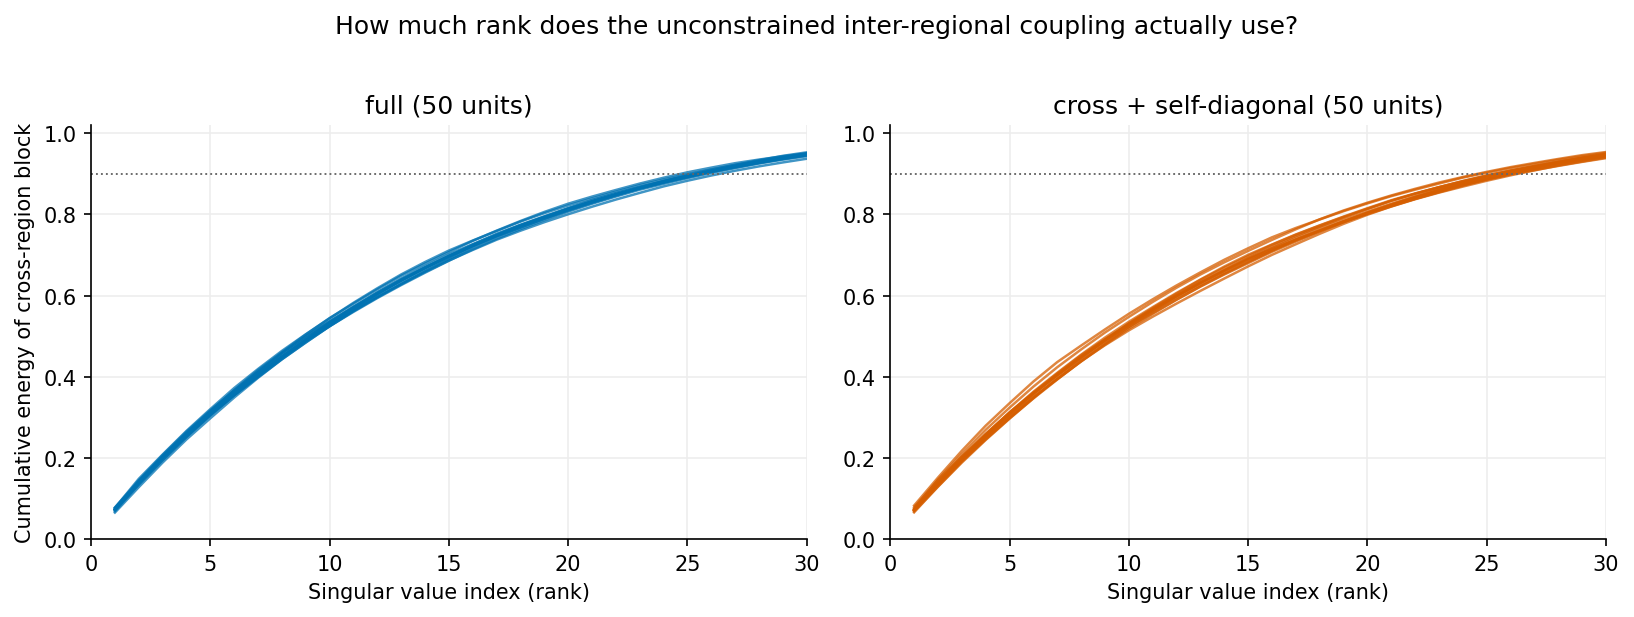

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), dpi=130)
for ax, label in zip(axes, ("h50_full", "h50_cross")):
    weight, mask, slices = dense_recurrent_matrix(CONNECTIVITY_RUNS[label])
    checkpoint = load_checkpoint(CONNECTIVITY_RUNS[label])
    regions_here = list(checkpoint["model_spec"]["region_order"])
    for source in regions_here:
        for target in regions_here:
            if source == target or not np.any(mask[slices[target], slices[source]]):
                continue
            block = weight[slices[target], slices[source]]
            singular = np.linalg.svd(block, compute_uv=False)
            energy = np.cumsum(singular**2) / np.sum(singular**2)
            ax.plot(np.arange(1, len(energy) + 1), energy, linewidth=1.2, alpha=0.75, color=ARCH_COLORS[architecture_of(label)])
    ax.axhline(0.9, color="0.4", linewidth=0.9, linestyle=":")
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Singular value index (rank)")
    ax.set_title(f"{ARCH_LABELS[architecture_of(label)]} (50 units)")
    ax.grid(color="0.93", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Cumulative energy of cross-region block")
fig.suptitle("How much rank does the unconstrained inter-regional coupling actually use?", y=1.02)
fig.tight_layout()
display_figure(fig)

Every fitted cross-region block is numerically full rank, and it takes roughly half of the
available singular directions to carry 90% of each block's energy. Read that as an upper
bound rather than a requirement: an unpenalized optimizer has no reason to concentrate a
block's energy, so a broad spectrum is what one would expect even if the *function* the
block performs is low-dimensional. It says the unconstrained fit did not spontaneously
discover a bottleneck; it does not say a bottleneck would hurt.

Part 2 tests that directly by imposing the rank constraint during training. If low ranks fit
nearly as well, the spread spectrum here was slack, not signal.

## 10. Follow-up runs this analysis calls for

Three limitations of the existing runs cannot be fixed by re-analysis:

1. **One seed per architecture.** Every conclusion above rests on a single initialization.
   The ensemble machinery (`initialization_mode="multiple"`) exists and should be used here.
2. **No capacity-matched fit.** Section 7 gives the exact hidden sizes; nothing has been
   trained at them yet.
3. **No held-out data.** All numbers above are in-sample. The training code already
   supports a temporal split through `pre_fixation_loss_weight` / `post_fixation_loss_weight`:
   fitting with `post_fixation_loss_weight = 0.0` trains only on pre-fixation bins, leaving
   the post-fixation half of every trajectory as genuine held-out data that the model must
   generate by rolling its own dynamics forward.

Both cells below are inert unless `RUN_TRAINING` is set to `True`. Each run is on the order
of hours on a GPU, so they belong in a batch job rather than in an interactive kernel.

In [24]:
RUN_TRAINING = False  # set True (ideally in a batch job) to fit the runs described above

connectivity_base = replace(
    base_settings,
    dataset_cfg_path=str(repo_root / "configs" / "dataset.yaml"),
    device="auto",
    target_mode="region_pcs",
    pca_n_components=42,
    temporal_basis_count=0,
    activation="tanh",
    rec_constrained=False,
    inp_constrained=False,
    spectral_radius=1.1,
    epochs=50_000,
    lr=3e-4,
    loss_fn="mse",
    temporal_derivative_loss_scale=1.0,
    temporal_curvature_loss_scale=0.5,
    correlation_loss_scale=0.0,
    variance_loss_scale=0.0,
    fr_reconstruction_loss_scale=0.0,
    l1_weight_scale=0.0,
    l2_weight_scale=0.0,
    gradient_clip_norm=1.0,
    initialization_mode="multiple",
    n_initializations=10,
    overwrite_seed_plan=False,
)

capacity_matched_plan = [
    {
        "scratch_id": f"modelsel_capmatch_{entry['connectivity']}_h{entry['matched_hidden_units']}_10init",
        "recurrent_connectivity": entry["connectivity"],
        "hidden_units": int(entry["matched_hidden_units"]),
        "k_effective": int(entry["k_effective"]),
    }
    for entry in matched
]
display(pd.DataFrame(capacity_matched_plan))

if RUN_TRAINING:
    from dal_monte_2022_analysis.ephys.modeling import train_fixation_mrnn_scratch

    for plan in capacity_matched_plan:
        settings = replace(
            connectivity_base,
            recurrent_connectivity=plan["recurrent_connectivity"],
            hidden_units=plan["hidden_units"],
        )
        train_fixation_mrnn_scratch(settings, scratch_id=plan["scratch_id"], overwrite=True)

,scratch_id,recurrent_connectivity,hidden_units,k_effective
0,modelsel_capmatch_full_h50_10init,full,50,49768
1,modelsel_capmatch_cross_region_with_self_diago...,cross_region_with_self_diagonal,57,50328
2,modelsel_capmatch_within_region_h90_10init,within_region,90,49848


In [25]:
# Held-out temporal split: fit on pre-fixation bins only, score on post-fixation bins.
holdout_plan = [
    {
        "scratch_id": f"modelsel_preonly_{arch}_h50_10init",
        "recurrent_connectivity": arch,
        "hidden_units": 50,
        "pre_fixation_loss_weight": 1.0,
        "post_fixation_loss_weight": 0.0,
    }
    for arch in ARCH_ORDER
]
display(pd.DataFrame(holdout_plan))

if RUN_TRAINING:
    from dal_monte_2022_analysis.ephys.modeling import train_fixation_mrnn_scratch

    for plan in holdout_plan:
        settings = replace(
            connectivity_base,
            recurrent_connectivity=plan["recurrent_connectivity"],
            hidden_units=plan["hidden_units"],
            pre_fixation_loss_weight=plan["pre_fixation_loss_weight"],
            post_fixation_loss_weight=plan["post_fixation_loss_weight"],
        )
        train_fixation_mrnn_scratch(settings, scratch_id=plan["scratch_id"], overwrite=True)


def held_out_temporal_r2(replay, *, held_out_mask=None) -> dict:
    """Pooled R^2 split by pre- vs post-fixation bins. Use on the pre-only runs above."""
    checkpoint = replay["checkpoint"]
    timeline = np.asarray(checkpoint["timeline_s"], dtype=float)
    if held_out_mask is None:
        held_out_mask = timeline >= 0.0
    out = {}
    for name, mask in (("train_prefixation", ~held_out_mask), ("heldout_postfixation", held_out_mask)):
        residual = 0.0
        total = 0.0
        for region in replay["region_order"]:
            y = np.asarray(checkpoint["target_by_region"][region], dtype=float)[:, mask, :]
            yhat = replay["output_by_region"][region].detach().cpu().numpy().astype(float)[:, mask, :]
            residual += float(np.sum((y - yhat) ** 2))
            total += float(np.sum((y - y.mean()) ** 2))
        out[f"{name}_r2"] = 1.0 - residual / total
    return out


# Demonstration on the existing (fully supervised) runs: both halves are in-sample here,
# so this only shows the helper works. It becomes a generalization measure once the
# `modelsel_preonly_*` runs above exist.
display(pd.DataFrame([{"label": label, **held_out_temporal_r2(replay)} for label, replay in CONNECTIVITY_REPLAYS.items()]))

,scratch_id,recurrent_connectivity,hidden_units,pre_fixation_loss_weight,post_fixation_loss_weight
0,modelsel_preonly_full_h50_10init,full,50,1.0,0.0
1,modelsel_preonly_cross_region_with_self_diagon...,cross_region_with_self_diagonal,50,1.0,0.0
2,modelsel_preonly_within_region_h50_10init,within_region,50,1.0,0.0


,label,train_prefixation_r2,heldout_postfixation_r2
0,h40_full,0.984982,0.987330
1,h40_cross,0.929632,0.928550
2,h40_within,0.937470,0.929731
3,h50_full,0.997387,0.997643
4,h50_cross,0.995282,0.995822
5,h50_within,0.931270,0.929951


# Part 2 — Inter-regional bottleneck dimension

Everything above concerns *which blocks exist*. This part concerns *how much information
passes through the cross-region blocks that do exist*, by constraining each inter-regional
block to rank `r` (`left @ right`, `recurrent_bottleneck_dim = r`).

**These runs are not directly comparable to Part 1.** They differ in three ways beyond the
bottleneck, all visible in the inventory: `l1_weight_scale = 0.01` (Part 1 used 0.0),
100,000 iterations for ranks 1-5 versus 50,000 for ranks 10-30, and the low-rank
parameterization itself. The bottleneck sweep is therefore internally comparable across
rank, and should not be read against the Part 1 numbers on the same axis.

In [26]:
bottleneck_confounds = inventory[inventory["run_id"].str.startswith("bottleneck_dim_")][
    ["label", "run_id", "connectivity", "bottleneck_dim", "hidden_units", "epochs", "l1_weight_scale", "lr"]
].sort_values("bottleneck_dim")
display(bottleneck_confounds)

,label,run_id,connectivity,bottleneck_dim,hidden_units,epochs,l1_weight_scale,lr
6,rank_1,bottleneck_dim_1,full,1.0,50,100000,0.01,0.0003
7,rank_2,bottleneck_dim_2,full,2.0,50,100000,0.01,0.0003
8,rank_3,bottleneck_dim_3,full,3.0,50,100000,0.01,0.0003
9,rank_4,bottleneck_dim_4,full,4.0,50,100000,0.01,0.0003
10,rank_5,bottleneck_dim_5,full,5.0,50,100000,0.01,0.0003
11,rank_10,bottleneck_dim_10,full,10.0,50,50000,0.01,0.0003
12,rank_20,bottleneck_dim_20,full,20.0,50,50000,0.01,0.0003
13,rank_30,bottleneck_dim_30,full,30.0,50,50000,0.01,0.0003


In [27]:
BOTTLENECK_REPLAYS = {label: replay_run(run_id) for label, run_id in BOTTLENECK_RUNS.items()}

bottleneck_rows = []
for label, run_id in BOTTLENECK_RUNS.items():
    replay = BOTTLENECK_REPLAYS[label]
    params = count_run_parameters(run_id)
    history = load_history(run_id)
    row = {
        "label": label,
        "bottleneck_dim": int(load_checkpoint(run_id)["settings"]["recurrent_bottleneck_dim"]),
        "epochs": int(load_checkpoint(run_id)["settings"]["epochs"]),
        "k_effective": params["k_effective"],
        "rec_cross_effective": params["rec_cross_effective"],
        "final_loss": float(history["loss"].iloc[-1]),
        "final_recon_loss": float(history["reconstruction_loss"].iloc[-1]),
    }
    row.update(pooled_fit_metrics(replay))
    row.update(pooled_fr_metrics(replay))
    row.update(information_criteria(row["rss"], row["n"], row["k_effective"]))
    bottleneck_rows.append(row)
bottleneck_table = pd.DataFrame(bottleneck_rows).sort_values("bottleneck_dim").reset_index(drop=True)
bottleneck_table["delta_r2_vs_previous"] = bottleneck_table["pooled_r2"].diff()
bottleneck_table["delta_bic"] = bottleneck_table["bic"] - bottleneck_table["bic"].min()
display(
    bottleneck_table[
        ["label", "bottleneck_dim", "epochs", "k_effective", "rec_cross_effective",
         "pooled_r2", "fr_pooled_r2", "mse", "delta_r2_vs_previous", "delta_bic"]
    ]
)

,label,bottleneck_dim,epochs,k_effective,rec_cross_effective,pooled_r2,fr_pooled_r2,mse,delta_r2_vs_previous,delta_bic
0,rank_1,1,100000,20956,1188,0.980718,0.999487,0.000246,NaN,0.000000
1,rank_2,2,100000,22120,2352,0.979314,0.999450,0.000264,-0.001405,16147.323298
2,rank_3,3,100000,23260,3492,0.986345,0.999637,0.000174,0.007031,7558.226092
3,rank_4,4,100000,24376,4608,0.986110,0.999631,0.000177,-0.000234,20500.072569
4,rank_5,5,100000,25468,5700,0.987476,0.999667,0.000160,0.001366,27105.956083
5,rank_10,10,50000,30568,10800,0.957303,0.998865,0.000545,-0.030174,144143.301303
6,rank_20,20,50000,38968,19200,0.801814,0.994731,0.002530,-0.155489,312463.773922
7,rank_30,30,50000,44968,25200,0.963896,0.999040,0.000461,0.162082,291608.454104


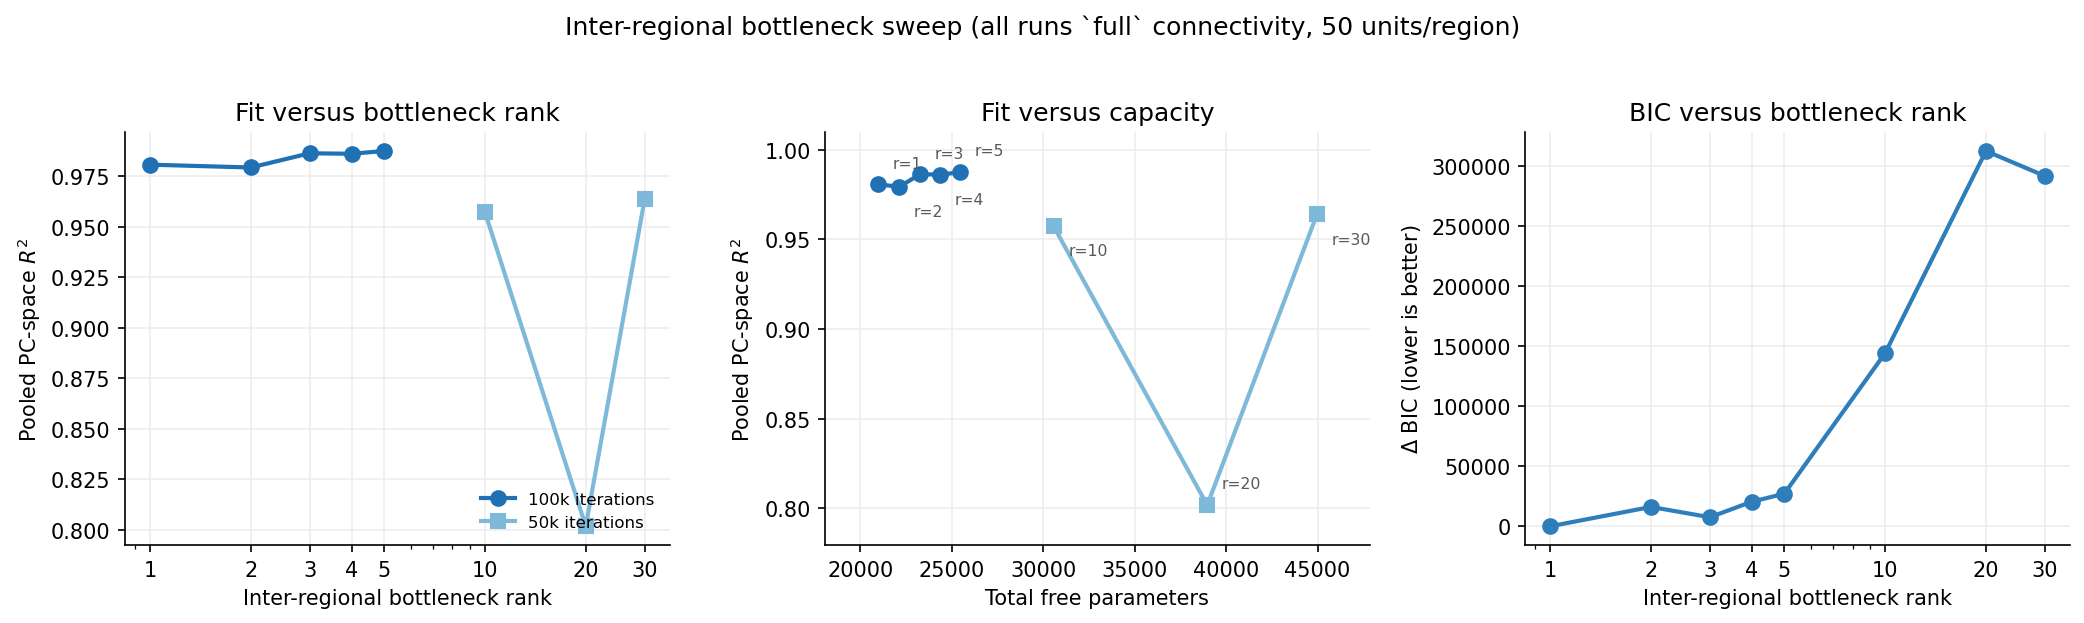

In [28]:
matched_epochs = bottleneck_table[bottleneck_table["epochs"] == bottleneck_table["epochs"].mode().iloc[0]]

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.0), dpi=130)

ax = axes[0]
for epochs, marker in ((100000, "o"), (50000, "s")):
    sub = bottleneck_table[bottleneck_table["epochs"] == epochs]
    if sub.empty:
        continue
    ax.plot(sub["bottleneck_dim"], sub["pooled_r2"], marker=marker, markersize=7, linewidth=2.0,
            color=SEQUENTIAL_HUE(0.75 if epochs == 100000 else 0.45),
            label=f"{epochs // 1000}k iterations")
ax.set_xscale("log")
ax.set_xticks(bottleneck_table["bottleneck_dim"], [str(d) for d in bottleneck_table["bottleneck_dim"]])
ax.set_xlabel("Inter-regional bottleneck rank")
ax.set_ylabel("Pooled PC-space $R^2$")
ax.set_title("Fit versus bottleneck rank")
ax.legend(frameon=False, fontsize=8, loc="lower right")

ax = axes[1]
for epochs, marker in ((100000, "o"), (50000, "s")):
    sub = bottleneck_table[bottleneck_table["epochs"] == epochs].sort_values("k_effective")
    if sub.empty:
        continue
    ax.plot(sub["k_effective"], sub["pooled_r2"], marker=marker, markersize=7, linewidth=2.0,
            color=SEQUENTIAL_HUE(0.75 if epochs == 100000 else 0.45))
for position, (_, row) in enumerate(bottleneck_table.iterrows()):
    # Alternate the label offset so the tightly spaced low ranks do not overlap.
    offset = (7, 8) if position % 2 == 0 else (7, -14)
    ax.annotate(f"r={int(row['bottleneck_dim'])}", (row["k_effective"], row["pooled_r2"]),
                textcoords="offset points", xytext=offset, fontsize=7.5, color="0.35")
ax.margins(x=0.12, y=0.12)
ax.set_xlabel("Total free parameters")
ax.set_ylabel("Pooled PC-space $R^2$")
ax.set_title("Fit versus capacity")

ax = axes[2]
ax.plot(bottleneck_table["bottleneck_dim"], bottleneck_table["delta_bic"], marker="o", markersize=7,
        linewidth=2.0, color=SEQUENTIAL_HUE(0.7))
ax.set_xscale("log")
ax.set_xticks(bottleneck_table["bottleneck_dim"], [str(d) for d in bottleneck_table["bottleneck_dim"]])
ax.set_xlabel("Inter-regional bottleneck rank")
ax.set_ylabel("$\\Delta$ BIC (lower is better)")
ax.set_title("BIC versus bottleneck rank")

for ax in axes:
    ax.grid(color="0.93", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Inter-regional bottleneck sweep (all runs `full` connectivity, 50 units/region)", y=1.03)
fig.tight_layout()
display_figure(fig)

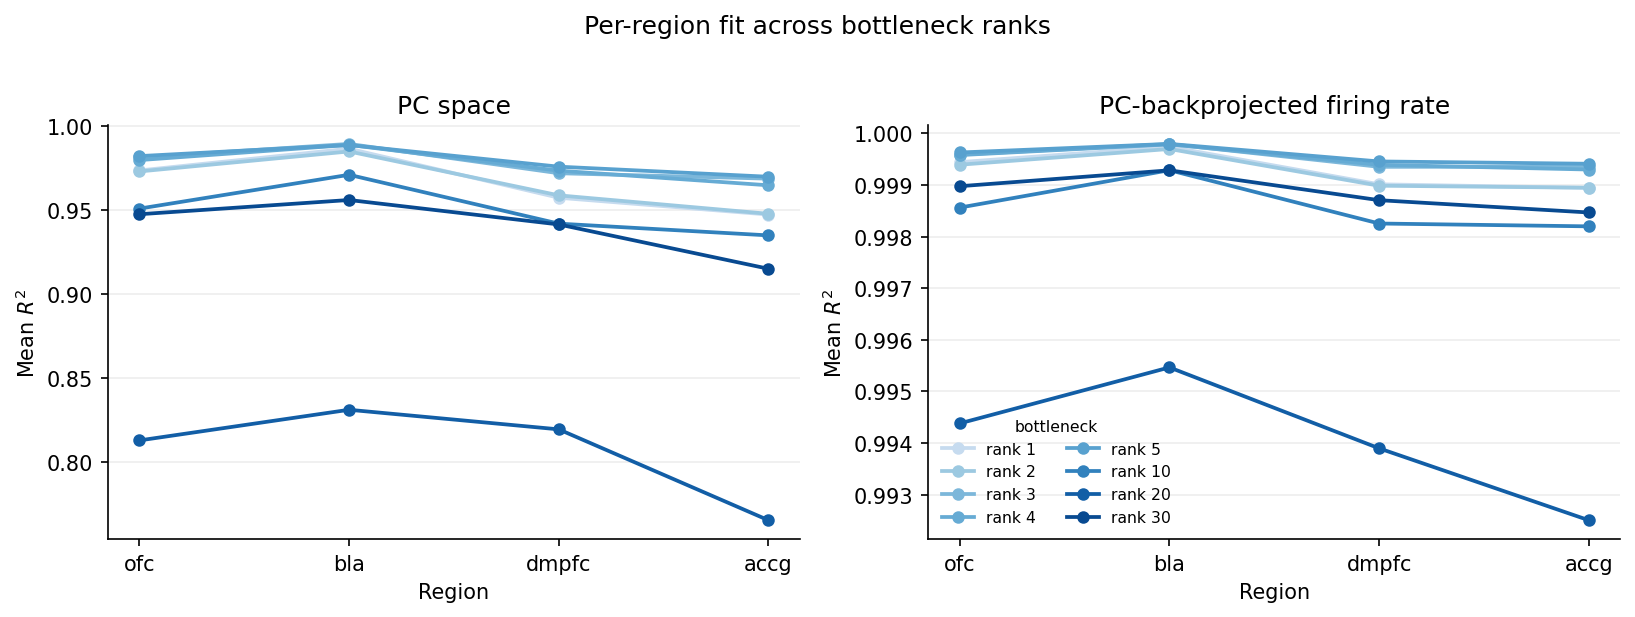

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), dpi=130)
for ax, space, title in zip(axes, ["region_pcs", "firing_rate"], ["PC space", "PC-backprojected firing rate"]):
    for label, replay in BOTTLENECK_REPLAYS.items():
        dim = int(load_checkpoint(BOTTLENECK_RUNS[label])["settings"]["recurrent_bottleneck_dim"])
        metrics = reconstruction_accuracy(replay) if space == "region_pcs" else pc_reconstructed_firing_rate_accuracy(replay)
        grouped = metrics.groupby("region", sort=False)["r2"].mean()
        shade = 0.25 + 0.65 * (np.log10(dim) / np.log10(30))
        ax.plot(grouped.index, grouped.to_numpy(), marker="o", markersize=5, linewidth=1.8,
                color=SEQUENTIAL_HUE(shade), label=f"rank {dim}")
    ax.set_xlabel("Region")
    ax.set_title(title)
    ax.grid(axis="y", color="0.93", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes:
    ax.set_ylabel("Mean $R^2$")
axes[1].legend(frameon=False, fontsize=7.5, ncol=2, title="bottleneck", title_fontsize=7.5, loc="lower left")
fig.suptitle("Per-region fit across bottleneck ranks", y=1.02)
fig.tight_layout()
display_figure(fig)

### 11a. The sweep is not monotone, and the training length explains why

Fit does not improve with rank: it is flat from rank 3 to 5, drops at 10 and 20, and
partially recovers at 30. A rank-20 model contains every rank-5 model as a special case, so
a genuinely converged sweep cannot behave this way. The `epochs` column identifies the
cause — ranks 1-5 were trained for 100,000 iterations and ranks 10-30 for 50,000.

So the sweep splits into one usable comparison and one unusable one. Within the
epoch-matched block (ranks 1-5) the ordering is interpretable. Across the two blocks it is
not, and the apparent "cost" of higher rank is a training-length artifact. Ranks 10, 20 and
30 need to be refit at 100,000 iterations before the sweep can be read end to end.

In [30]:
epoch_groups = bottleneck_table.groupby("epochs", sort=False)
for epochs, group in epoch_groups:
    group = group.sort_values("bottleneck_dim").copy()
    group["marginal_r2_gain"] = group["pooled_r2"].diff()
    group["cumulative_gain_from_lowest"] = group["pooled_r2"] - group["pooled_r2"].iloc[0]
    print(f"--- epoch-matched block: {epochs} iterations ---")
    display(
        group[
            ["label", "bottleneck_dim", "k_effective", "pooled_r2", "fr_pooled_r2",
             "marginal_r2_gain", "cumulative_gain_from_lowest"]
        ].reset_index(drop=True)
    )

comparable = bottleneck_table[bottleneck_table["epochs"] == 100_000].sort_values("bottleneck_dim")
best_comparable_r2 = comparable["pooled_r2"].max()
knee = comparable[comparable["pooled_r2"] >= best_comparable_r2 - 0.005]["bottleneck_dim"].min()
print(
    "Within the 100k-iteration block, the smallest rank within 0.005 pooled R^2 "
    f"of the best is rank {int(knee)} "
    f"(best R^2 = {best_comparable_r2:.4f} at rank "
    f"{int(comparable.loc[comparable['pooled_r2'].idxmax(), 'bottleneck_dim'])})."
)

refit_plan = [
    {
        "scratch_id": f"modelsel_bottleneck_dim_{dim}_100k",
        "recurrent_connectivity": "full",
        "hidden_units": 50,
        "recurrent_bottleneck_dim": dim,
        "epochs": 100_000,
        "l1_weight_scale": 0.01,
    }
    for dim in (10, 20, 30)
]
display(pd.DataFrame(refit_plan))

if RUN_TRAINING:
    from dal_monte_2022_analysis.ephys.modeling import train_fixation_mrnn_scratch

    for plan in refit_plan:
        settings = replace(
            connectivity_base,
            initialization_mode="single",
            recurrent_connectivity=plan["recurrent_connectivity"],
            hidden_units=plan["hidden_units"],
            recurrent_bottleneck_dim=plan["recurrent_bottleneck_dim"],
            epochs=plan["epochs"],
            l1_weight_scale=plan["l1_weight_scale"],
        )
        train_fixation_mrnn_scratch(settings, scratch_id=plan["scratch_id"], overwrite=True)

--- epoch-matched block: 100000 iterations ---


,label,bottleneck_dim,k_effective,pooled_r2,fr_pooled_r2,marginal_r2_gain,cumulative_gain_from_lowest
0,rank_1,1,20956,0.980718,0.999487,NaN,0.000000
1,rank_2,2,22120,0.979314,0.999450,-0.001405,-0.001405
2,rank_3,3,23260,0.986345,0.999637,0.007031,0.005626
3,rank_4,4,24376,0.986110,0.999631,-0.000234,0.005392
4,rank_5,5,25468,0.987476,0.999667,0.001366,0.006758


--- epoch-matched block: 50000 iterations ---


,label,bottleneck_dim,k_effective,pooled_r2,fr_pooled_r2,marginal_r2_gain,cumulative_gain_from_lowest
0,rank_10,10,30568,0.957303,0.998865,NaN,0.000000
1,rank_20,20,38968,0.801814,0.994731,-0.155489,-0.155489
2,rank_30,30,44968,0.963896,0.999040,0.162082,0.006594


Within the 100k-iteration block, the smallest rank within 0.005 pooled R^2 of the best is rank 3 (best R^2 = 0.9875 at rank 5).


,scratch_id,recurrent_connectivity,hidden_units,recurrent_bottleneck_dim,epochs,l1_weight_scale
0,modelsel_bottleneck_dim_10_100k,full,50,10,100000,0.01
1,modelsel_bottleneck_dim_20_100k,full,50,20,100000,0.01
2,modelsel_bottleneck_dim_30_100k,full,50,30,100000,0.01


## 12. Decision summary

In [31]:
decision = merged[["label", "connectivity", "hidden_units", "k_effective", "pooled_r2", "fr_pooled_r2"]].copy()
decision = decision.merge(
    pd.DataFrame(conv_rows)[["label", "rel_improvement_last_2k", "final_over_best"]], on="label"
)
decision["r2_per_10k_params"] = decision["pooled_r2"] / (decision["k_effective"] / 10_000)
decision = decision.sort_values(["hidden_units", "connectivity"]).reset_index(drop=True)
display(decision)

print("\nGrouped lesions of the fitted h50 `full` model (saturated - see Section 8):")
display(ablation_table[ablation_table["ablation"].isin(["none (intact)", "all cross-region", "all within-region"])])

print("Graded lesion, pooled R^2 at each scaling factor:")
display(dose_table.pivot(index="scale", columns="group", values="pooled_r2").sort_index(ascending=False))

print("Per-block lesion impact by block type (4 within-region vs 12 cross-region, all 50x50):")
display(
    group_stats[
        ["depth", "metric", "mean_within", "mean_cross", "mannwhitney_p_exact", "cliffs_delta", "hedges_g"]
    ]
)

print(
    "Median rank carrying 90% of cross-region block energy (h50 full): "
    f"{int(rank_table[rank_table['label'] == 'h50_full']['n_sv_for_90pct_energy'].median())} of 50"
)

print(
    "Bottleneck sweep, epoch-matched block only (100k iterations, ranks 1-5): "
    f"smallest rank within 0.005 pooled R^2 of the best is rank {int(knee)}. "
    "Ranks 10-30 are not comparable until refit."
)

,label,connectivity,hidden_units,k_effective,pooled_r2,fr_pooled_r2,rel_improvement_last_2k,final_over_best,r2_per_10k_params
0,h40_cross,cross_region_with_self_diagonal,40,27208,0.929043,0.998114,-3.092857,4.127378,0.341459
1,h40_full,full,40,33448,0.986324,0.999636,0.044338,1.001583,0.294883
2,h40_within,within_region,40,14248,0.933089,0.998221,0.301656,1.210760,0.654891
3,h50_cross,cross_region_with_self_diagonal,50,39968,0.995591,0.999883,0.118009,1.408182,0.249097
4,h50_full,full,50,49768,0.997534,0.999934,-0.025748,1.094783,0.200437
5,h50_within,within_region,50,19768,0.930545,0.998153,0.149056,2.777828,0.470733



Grouped lesions of the fitted h50 `full` model (saturated - see Section 8):


,ablation,n_blocks,pooled_r2,delta_r2,rss_over_tss,pooled_correlation,prediction_amplitude,mse,mse_ratio_to_intact
0,none (intact),0,0.997534,0.000000,0.002466,0.998766,1.077421,0.000031,1.000000
1,all cross-region,12,-0.651269,-1.648802,1.651269,0.265176,0.479341,0.021081,669.515306
2,all within-region,4,-2.282027,-3.279561,3.282027,0.278510,0.962505,0.041900,1330.714599


Graded lesion, pooled R^2 at each scaling factor:


group,cross-region,within-region
scale,,
1.00,0.997534,0.997534
0.95,0.911740,0.959469
0.90,0.681385,0.822329
0.80,0.326021,0.442493
0.60,0.039029,-0.077106
0.40,-0.176355,-0.626919
0.20,-0.392420,-1.311332
0.00,-0.651269,-2.282027


Per-block lesion impact by block type (4 within-region vs 12 cross-region, all 50x50):


,depth,metric,mean_within,mean_cross,mannwhitney_p_exact,cliffs_delta,hedges_g
0,deletion (scale 0),delta R2,-1.893714,-2.032892,0.379121,0.333333,0.629140
1,deletion (scale 0),delta correlation,-0.623566,-0.655619,0.170330,0.500000,0.783837
2,graded (scale 0.9),delta R2,-0.043122,-0.030546,0.002198,-0.958333,-2.539813
3,graded (scale 0.9),delta correlation,-0.021682,-0.015351,0.002198,-0.958333,-2.563079


Median rank carrying 90% of cross-region block energy (h50 full): 26 of 50
Bottleneck sweep, epoch-matched block only (100k iterations, ranks 1-5): smallest rank within 0.005 pooled R^2 of the best is rank 3. Ranks 10-30 are not comparable until refit.


### What this notebook does and does not establish

**Established from the saved runs.**
- The connectivity comparison used **no** inter-regional bottleneck. All region-to-region
  blocks were free, full-rank matrices, and the checkpoints carry
  `recurrent_bottleneck_dim = None` (Section 2a).
- At 50 units per region, `full` and `cross + self-diagonal` both reach pooled PC-space
  R^2 above 0.99, while `within_region` plateaus near 0.93 despite converging. Regions
  cannot reproduce each other's trajectories without inter-regional coupling — and the
  `cross + self-diagonal` result sharpens that: dense *internal* connectivity is largely
  dispensable as long as cross-regional coupling is present, which is the more interesting
  half of the finding.
- The fitted `full` solution is not decomposable: no single block can be removed without
  collapsing the dynamics (Section 8). Under a graded 10% attenuation, where the metric is
  not saturated, the four within-region blocks are individually more load-bearing than the
  twelve inter-regional ones, with near-complete separation between the groups (Section 8a).
  All sixteen blocks are dense 50 x 50 matrices, so that comparison is parameter-matched by
  construction.
- The unconstrained inter-regional blocks stay full rank and spread their energy over
  roughly half the available directions (Section 9), yet an explicitly rank-constrained fit
  reaches the same quality at a very low rank (Part 2) — so that spread is slack, not a
  requirement.

**Not established, and what it would take.**
- Whether the architecture ranking survives at matched capacity. `within_region` at 50 units
  has 40% of `full`'s parameters, so its worse fit is confounded with its smaller size.
  Section 7 gives the three hidden sizes (50 / 57 / 90) that equalize the budget; those runs
  have not been fit. This is the single most important gap.
- Whether it survives across seeds. One initialization per architecture, and the 40-unit
  `cross + self-diagonal` run was still oscillating at its final iterate. Section 10 uses 10
  initializations.
- Out-of-sample generalization. Every number here is in-sample. The pre-fixation-only
  protocol in Section 10 turns the post-fixation half of each trajectory into held-out data
  with no change to the training code.
- The bottleneck sweep end to end. Ranks 1-5 and ranks 10-30 were trained for different
  numbers of iterations; only the epoch-matched block is currently readable (Section 11a).

# Part 3 — Assembled figure: architectures and their performance

One figure row with four columns. Columns 1-3 are schematics of the three recurrent
connectivity architectures; column 4 compares their reconstruction quality with a paired
statistical test across the twelve region x condition cells.

It is written to the project's standard analysis-output tree
(`<analysis_output_root>/ephys/modeling/fixation_mrnn/plots/model_selection/`) as both PDF
and PNG, using `configs/plotting.yaml` so the vector output stays Illustrator-editable:
`pdf.fonttype: 42` and `ps.fonttype: 42` keep text as editable text rather than outlines,
`svg.fonttype: none` does the same for SVG, `path.simplify: false` preserves vertices, and
`disable_pdf_clipping_masks: true` strips clip paths that otherwise arrive in Illustrator as
masks over every artist.

In [32]:
import itertools

import matplotlib as mpl
from matplotlib.patches import Arc, Circle, FancyArrowPatch
from scipy import stats

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.plotting.common import apply_plotting_config
from dal_monte_2022_analysis.ephys.plotting.fixation_mrnn import DEFAULT_REGION_COLORS
from dal_monte_2022_analysis.runtime.io.plot_output import save_figure

plotting_cfg = apply_plotting_config(load_config(repo_root / "configs" / "plotting.yaml"))
FIGURE_DIR = resolve_fixation_mrnn_output_root(base_settings) / "plots" / "model_selection"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(FIGURE_DIR)
print({key: mpl.rcParams[key] for key in ("pdf.fonttype", "ps.fonttype", "svg.fonttype", "path.simplify")})

/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/plots/model_selection
{'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none', 'path.simplify': False}


In [33]:
NODE_POSITIONS = {"ofc": (-1.0, 1.0), "bla": (1.0, 1.0), "dmpfc": (1.0, -1.0), "accg": (-1.0, -1.0)}
NODE_RADIUS = 0.40
LOOP_RADIUS = 0.26
EDGE_CURVATURE = 0.18
ABSENT_COLOR = "#D2D2D2"
SCHEMATIC_SPECS = {
    "full": {"cross": True, "within": "dense"},
    "within_region": {"cross": False, "within": "dense"},
    "cross_region_with_self_diagonal": {"cross": True, "within": "diagonal"},
}


def _bezier_endpoints(start, end, rad, margin):
    """Endpoints on each node's perimeter, tangent to the arc3 Bezier path.

    ``arc3`` draws a quadratic Bezier whose control point sits ``rad * |d|`` off the chord
    midpoint, so the tangent at each end points to/from that control point. Trimming along
    those tangents places the arrowhead exactly on the node edge instead of under it.
    """
    start = np.asarray(start, dtype=float)
    end = np.asarray(end, dtype=float)
    delta = end - start
    perpendicular = np.array([-delta[1], delta[0]])
    control = (start + end) / 2.0 + rad * perpendicular
    dir_start = control - start
    dir_end = end - control
    dir_start = dir_start / np.linalg.norm(dir_start)
    dir_end = dir_end / np.linalg.norm(dir_end)
    return start + dir_start * margin, end - dir_end * margin


def draw_cross_arrow(ax, source, target, *, color, linewidth, linestyle, zorder):
    pos_a, pos_b = _bezier_endpoints(
        NODE_POSITIONS[source], NODE_POSITIONS[target], EDGE_CURVATURE, NODE_RADIUS + 0.035
    )
    ax.add_patch(
        FancyArrowPatch(
            posA=pos_a, posB=pos_b, connectionstyle=f"arc3,rad={EDGE_CURVATURE}",
            arrowstyle="-|>", mutation_scale=9, linewidth=linewidth, linestyle=linestyle,
            color=color, zorder=zorder, joinstyle="round", capstyle="round",
        )
    )


def draw_self_loop(ax, region, *, color, linewidth, linestyle, zorder):
    """Draw a self-recurrence loop just outside the node, opening away from the centre."""
    centre = np.asarray(NODE_POSITIONS[region], dtype=float)
    outward = centre / np.linalg.norm(centre)
    loop_centre = centre + outward * (NODE_RADIUS + LOOP_RADIUS * 0.82)
    phi = float(np.degrees(np.arctan2(outward[1], outward[0])))
    theta1, theta2 = phi - 145.0, phi + 145.0
    ax.add_patch(
        Arc(tuple(loop_centre), 2 * LOOP_RADIUS, 2 * LOOP_RADIUS, theta1=theta1, theta2=theta2,
            linewidth=linewidth, linestyle=linestyle, edgecolor=color, zorder=zorder)
    )
    head_angle = np.radians(theta1)
    head = loop_centre + LOOP_RADIUS * np.array([np.cos(head_angle), np.sin(head_angle)])
    tangent = np.array([np.sin(head_angle), -np.cos(head_angle)])
    ax.add_patch(
        FancyArrowPatch(posA=head - tangent * 0.012, posB=head, arrowstyle="-|>",
                        mutation_scale=9, linewidth=linewidth, color=color, zorder=zorder)
    )


def draw_architecture_schematic(ax, architecture, *, title, subtitle):
    spec = SCHEMATIC_SPECS[architecture]
    for source in targets_region_order:
        for target in targets_region_order:
            if source == target:
                continue
            present = spec["cross"]
            draw_cross_arrow(
                ax, source, target,
                color=DEFAULT_REGION_COLORS[source] if present else ABSENT_COLOR,
                linewidth=1.4 if present else 0.9,
                linestyle="-" if present else (0, (2, 2)),
                zorder=3 if present else 1,
            )
    for region in targets_region_order:
        dense = spec["within"] == "dense"
        draw_self_loop(ax, region, color=DEFAULT_REGION_COLORS[region],
                       linewidth=2.3 if dense else 1.1,
                       linestyle="-" if dense else (0, (2.2, 1.8)), zorder=4)
    for region in targets_region_order:
        x, y = NODE_POSITIONS[region]
        ax.add_patch(Circle((x, y), NODE_RADIUS, facecolor="white",
                            edgecolor=DEFAULT_REGION_COLORS[region], linewidth=1.9, zorder=5))
        ax.text(x, y, region.upper(), ha="center", va="center", fontsize=8,
                color=DEFAULT_REGION_COLORS[region], zorder=6)
    ax.set_xlim(-2.05, 2.05)
    ax.set_ylim(-2.45, 2.05)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=10.5, pad=4)
    ax.text(0.5, 0.055, subtitle, transform=ax.transAxes, ha="center", va="top",
            fontsize=8, color="0.3", linespacing=1.45)


targets_region_order = list(load_checkpoint(CONNECTIVITY_RUNS["h50_full"])["model_spec"]["region_order"])
print("regions:", targets_region_order)

regions: ['ofc', 'bla', 'dmpfc', 'accg']


In [34]:
FIGURE_RUNS = {
    "full": "h50_full",
    "cross_region_with_self_diagonal": "h50_cross",
    "within_region": "h50_within",
}
FIGURE_ARCH_ORDER = ["full", "cross_region_with_self_diagonal", "within_region"]

cell_rows = []
for architecture, label in FIGURE_RUNS.items():
    metrics = reconstruction_accuracy(CONNECTIVITY_REPLAYS[label])
    metrics["architecture"] = architecture
    cell_rows.append(metrics)
cell_r2 = pd.concat(cell_rows, ignore_index=True)
paired_r2 = cell_r2.pivot_table(index=["region", "condition"], columns="architecture", values="r2")[
    FIGURE_ARCH_ORDER
]
display(paired_r2.round(4))
print("mean across the 12 region x condition cells:")
display(paired_r2.mean().round(4))

# The three architectures are scored on the same twelve region x condition cells, so the
# comparison is paired: Friedman omnibus, then Wilcoxon signed-rank post-hoc with Holm.
friedman = stats.friedmanchisquare(*[paired_r2[a].to_numpy() for a in FIGURE_ARCH_ORDER])
pair_rows = []
for first, second in itertools.combinations(FIGURE_ARCH_ORDER, 2):
    signed_rank = stats.wilcoxon(paired_r2[first], paired_r2[second])
    pair_rows.append(
        {
            "architecture_a": first,
            "architecture_b": second,
            "mean_a": float(paired_r2[first].mean()),
            "mean_b": float(paired_r2[second].mean()),
            "n_cells_a_greater": int((paired_r2[first] > paired_r2[second]).sum()),
            "n_cells": int(len(paired_r2)),
            "wilcoxon_w": float(signed_rank.statistic),
            "p_raw": float(signed_rank.pvalue),
        }
    )
pairwise_stats = pd.DataFrame(pair_rows)


def holm_adjust(p_values) -> np.ndarray:
    """Holm-Bonferroni step-down adjustment, order preserved."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running = 0.0
    for rank, index in enumerate(order):
        running = max(running, min(1.0, (len(p_values) - rank) * p_values[index]))
        adjusted[index] = running
    return adjusted


pairwise_stats["p_holm"] = holm_adjust(pairwise_stats["p_raw"])
print(f"Friedman chi2 = {friedman.statistic:.3f}, p = {friedman.pvalue:.3g} "
      f"(k=3 architectures, n={len(paired_r2)} paired cells)")
display(pairwise_stats)
print(
    f"Exact floor for Wilcoxon signed-rank at n={len(paired_r2)}: "
    f"p_min = {2 / 2 ** len(paired_r2):.6f}. Every pair sits at that floor because the "
    "ordering is identical in all twelve cells, so read the consistency, not the p-value."
)

architecture                   full  cross_region_with_self_diagonal  within_region
region condition                                                                   
accg   face_interactive      0.9828                           0.9739         0.9314
       face_non_interactive  0.9968                           0.9957         0.9925
       object                0.9969                           0.9941         0.9917
bla    face_interactive      0.9967                           0.9943         0.9354
       face_non_interactive  0.9990                           0.9986         0.9818
       object                0.9994                           0.9974         0.7391
dmpfc  face_interactive      0.9879                           0.9829         0.9248
       face_non_interactive  0.9979                           0.9969         0.9922
       object                0.9976                           0.9943         0.9862
ofc    face_interactive      0.9930                           0.9899         0.9512
       face_non_interactive  0.9982                           0.9973         0.9821
       object                0.9989                           0.9964         0.9920

mean across the 12 region x condition cells:


architecture
full                               0.9954
cross_region_with_self_diagonal    0.9926
within_region                      0.9500
dtype: float64

Friedman chi2 = 24.000, p = 6.14e-06 (k=3 architectures, n=12 paired cells)


,architecture_a,architecture_b,mean_a,mean_b,n_cells_a_greater,n_cells,wilcoxon_w,p_raw,p_holm
0,full,cross_region_with_self_diagonal,0.995419,0.992634,12,12,0.0,0.000488,0.001465
1,full,within_region,0.995419,0.950040,12,12,0.0,0.000488,0.001465
2,cross_region_with_self_diagonal,within_region,0.992634,0.950040,12,12,0.0,0.000488,0.001465


Exact floor for Wilcoxon signed-rank at n=12: p_min = 0.000488. Every pair sits at that floor because the ordering is identical in all twelve cells, so read the consistency, not the p-value.


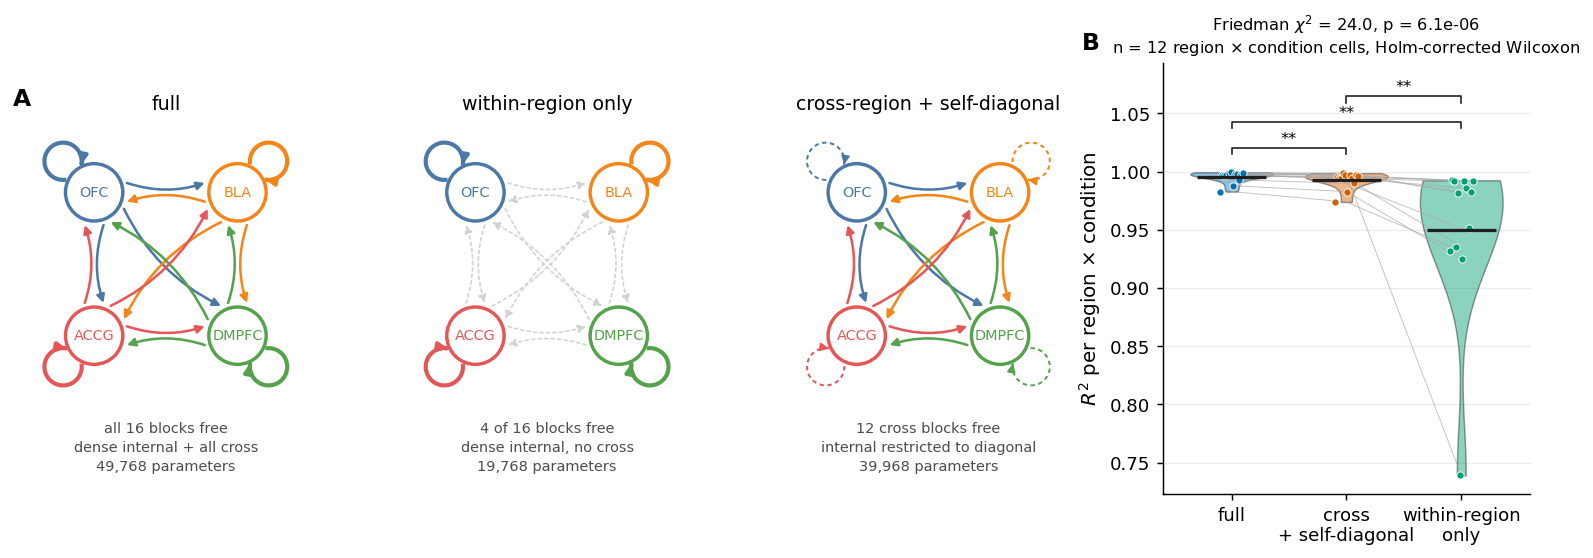

/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/plots/model_selection/architecture_schematics_and_performance.pdf
/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/plots/model_selection/architecture_schematics_and_performance.png


In [35]:
def significance_stars(p_value: float) -> str:
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "n.s."


fig = plt.figure(figsize=(15.0, 4.3), dpi=300)
grid = fig.add_gridspec(1, 4, width_ratios=[1.0, 1.0, 1.0, 1.25], wspace=0.28)

schematic_titles = {
    "full": "full",
    "within_region": "within-region only",
    "cross_region_with_self_diagonal": "cross-region + self-diagonal",
}
schematic_subtitles = {}
for architecture, label in FIGURE_RUNS.items():
    counts = param_table.set_index("label").loc[label]
    if architecture == "full":
        structure = "all 16 blocks free\ndense internal + all cross"
    elif architecture == "within_region":
        structure = "4 of 16 blocks free\ndense internal, no cross"
    else:
        structure = "12 cross blocks free\ninternal restricted to diagonal"
    schematic_subtitles[architecture] = f"{structure}\n{int(counts['k_effective']):,} parameters"

for column, architecture in enumerate(["full", "within_region", "cross_region_with_self_diagonal"]):
    ax = fig.add_subplot(grid[0, column])
    draw_architecture_schematic(
        ax, architecture,
        title=schematic_titles[architecture],
        subtitle=schematic_subtitles[architecture],
    )
    if column == 0:
        ax.text(-0.02, 1.02, "A", transform=ax.transAxes, fontsize=13,
                fontweight="bold", va="bottom", ha="left")

ax = fig.add_subplot(grid[0, 3])
positions = np.arange(len(FIGURE_ARCH_ORDER))
violin = ax.violinplot(
    [paired_r2[a].to_numpy() for a in FIGURE_ARCH_ORDER],
    positions=positions, widths=0.72, showextrema=False, showmedians=False,
)
for body, architecture in zip(violin["bodies"], FIGURE_ARCH_ORDER):
    body.set_facecolor(ARCH_COLORS[architecture])
    body.set_edgecolor("#1F1F1F")
    body.set_linewidth(0.8)
    body.set_alpha(0.45)
    # matplotlib's KDE extends past the data; clip each body to its own range so the
    # violins cannot imply R^2 values above 1 or below the worst observed cell.
    values = paired_r2[architecture].to_numpy()
    vertices = body.get_paths()[0].vertices
    vertices[:, 1] = np.clip(vertices[:, 1], values.min(), values.max())

# Paired cells connected across architectures, because the test is a paired one.
for _, row in paired_r2.iterrows():
    ax.plot(positions, [row[a] for a in FIGURE_ARCH_ORDER], color="0.65",
            linewidth=0.5, alpha=0.7, zorder=2)
for position, architecture in zip(positions, FIGURE_ARCH_ORDER):
    values = paired_r2[architecture].to_numpy()
    offsets = np.linspace(-0.10, 0.10, len(values))
    ax.scatter(position + offsets, values, s=16, color=ARCH_COLORS[architecture],
               edgecolor="white", linewidth=0.5, zorder=3)
    ax.hlines(float(np.mean(values)), position - 0.3, position + 0.3,
              color="#1F1F1F", linewidth=1.8, zorder=4)

y_low = float(paired_r2.to_numpy().min())
y_high = float(paired_r2.to_numpy().max())
span = y_high - y_low
bracket_base = y_high + 0.06 * span
for step, (_, row) in enumerate(pairwise_stats.iterrows()):
    i = FIGURE_ARCH_ORDER.index(row["architecture_a"])
    j = FIGURE_ARCH_ORDER.index(row["architecture_b"])
    height = bracket_base + step * 0.085 * span
    ax.plot([i, i, j, j], [height, height + 0.02 * span, height + 0.02 * span, height],
            color="#1F1F1F", linewidth=0.9, clip_on=False)
    ax.text((i + j) / 2.0, height + 0.025 * span, significance_stars(row["p_holm"]),
            ha="center", va="bottom", fontsize=9)

ax.set_xticks(positions, [ARCH_LABELS[a].replace(" + ", "\n+ ").replace(" only", "\nonly")
                          for a in FIGURE_ARCH_ORDER])
ax.set_ylabel("$R^2$ per region $\\times$ condition")
ax.set_ylim(y_low - 0.06 * span, bracket_base + 0.30 * span)
ax.set_xlim(-0.6, len(FIGURE_ARCH_ORDER) - 0.4)
ax.grid(axis="y", color="0.92", linewidth=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title(
    f"Friedman $\\chi^2$ = {friedman.statistic:.1f}, p = {friedman.pvalue:.1e}\n"
    f"n = {len(paired_r2)} region $\\times$ condition cells, Holm-corrected Wilcoxon",
    fontsize=9,
)
ax.text(-0.22, 1.02, "B", transform=ax.transAxes, fontsize=13, fontweight="bold",
        va="bottom", ha="left")

saved = []
for extension in ("pdf", "png"):
    saved.append(
        save_figure(
            fig,
            FIGURE_DIR / f"architecture_schematics_and_performance.{extension}",
            ext=extension,
            dpi=300,
            facecolor="white",
            edgecolor="white",
            transparent=False,
        )
    )
display_figure(fig, dpi=130)
for path in saved:
    print(path)

In [36]:
# Persist the numbers behind panel B next to the figure, so the statistics can be
# re-read without re-running the notebook.
stats_path = FIGURE_DIR / "architecture_performance_stats.csv"
cells_path = FIGURE_DIR / "architecture_performance_cells.csv"
pairwise_stats.assign(
    friedman_chi2=float(friedman.statistic),
    friedman_p=float(friedman.pvalue),
    n_paired_cells=int(len(paired_r2)),
).to_csv(stats_path, index=False)
paired_r2.reset_index().to_csv(cells_path, index=False)
print(stats_path)
print(cells_path)

/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/plots/model_selection/architecture_performance_stats.csv
/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/plots/model_selection/architecture_performance_cells.csv


**Reading panel B.** Every one of the twelve region x condition cells orders the three
architectures identically — `full` > `cross + self-diagonal` > `within-region only` — which
is why all three Wilcoxon comparisons return W = 0 and sit exactly at the exact test's floor
for n = 12. The stars mark that consistency, not strength of evidence; with a single seed per
architecture the correct summary is the size and consistency of the gap, and the multi-seed
ensemble in Section 10 is what would license an inferential claim.

The gap that matters is between `within-region only` and the other two. Dropping
inter-regional coupling costs about 0.045 in mean R^2 and is the only architecture whose
worst cells fall below 0.8. Restricting *internal* coupling to a diagonal costs almost
nothing by comparison. Note also that `full` carries 2.5x the parameters of
`within_region`, so panel B on its own does not separate architecture from capacity —
Section 7's matched-budget runs are what close that gap.